In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv('tmdb_train_data.csv')

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month
df['release_weekday'] = df['release_date'].dt.weekday

df = df.dropna(subset=['vote_average'])

cat_cols = ['genres', 'director', 'country']
for col in cat_cols:
    df[col] = df[col].fillna('Unknown')
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

features = ['genres', 'director', 'country', 'release_year', 'release_month', 'release_weekday']
X = df[features]
y = df['vote_average']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.7
)

model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=50)

y_pred = model.predict(X_valid)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
mae = mean_absolute_error(y_valid, y_pred)
r2 = r2_score(y_valid, y_pred)

print(f'Validation RMSE: {rmse:.4f}')
print(f'Validation MAE: {mae:.4f}')
print(f'Validation R^2: {r2:.4f}')


[0]	validation_0-rmse:3.49080
[50]	validation_0-rmse:3.27583
[100]	validation_0-rmse:3.25336
[150]	validation_0-rmse:3.24563
[200]	validation_0-rmse:3.24145
[250]	validation_0-rmse:3.24264
[300]	validation_0-rmse:3.24402
[350]	validation_0-rmse:3.24393
[400]	validation_0-rmse:3.24560
[450]	validation_0-rmse:3.25043
[499]	validation_0-rmse:3.25468
Validation RMSE: 3.2547
Validation MAE: 2.6765
Validation R^2: 0.1407


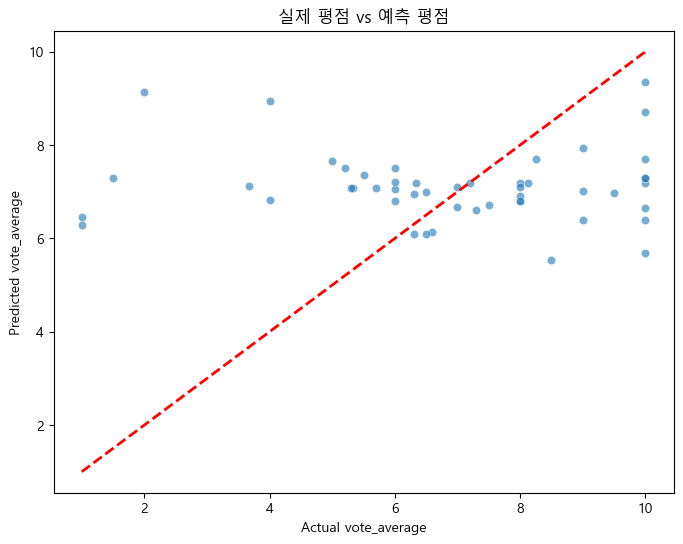

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_valid, y=y_pred, alpha=0.6)
plt.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], 'r--', lw=2)
plt.xlabel('실제 평점')
plt.ylabel('예측 평점')
plt.title('실제 평점 vs 예측 평점')
plt.show()

In [ ]:
#catboost 모델

import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('tmdb_train_data.csv')

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month
df['release_weekday'] = df['release_date'].dt.weekday

df = df.dropna(subset=['vote_average'])

cat_features = ['genres', 'director', 'country']
df['genres'] = df['genres'].fillna('Unknown').apply(lambda x: x.split('|')[0] if isinstance(x, str) and x != '' else 'Unknown')
df['director'] = df['director'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

for col in ['genres', 'director', 'country']:
    df[col] = df[col].fillna('Unknown')
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

features = ['genres', 'director', 'country', 'release_year', 'release_month', 'release_weekday']
X = df[features]
y = df['vote_average']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

cat_features_indices = [X_train.columns.get_loc(col) for col in cat_features]

train_pool = Pool(X_train, y_train, cat_features=cat_features_indices)
valid_pool = Pool(X_valid, y_valid, cat_features=cat_features_indices)

model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='RMSE',
    random_seed=42,
    early_stopping_rounds=50,
    verbose=50
)

model.fit(train_pool, eval_set=valid_pool)

y_pred = model.predict(X_valid)

rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
mae = mean_absolute_error(y_valid, y_pred)
r2 = r2_score(y_valid, y_pred)

print(f'Validation RMSE: {rmse:.4f}')
print(f'Validation MAE: {mae:.4f}')
print(f'Validation R^2: {r2:.4f}')

0:	learn: 3.4922437	test: 3.4901547	best: 3.4901547 (0)	total: 234ms	remaining: 3m 53s
50:	learn: 3.1927315	test: 3.2199633	best: 3.2199633 (50)	total: 3.02s	remaining: 56.1s
100:	learn: 3.1555712	test: 3.1997714	best: 3.1997714 (100)	total: 5.55s	remaining: 49.4s
150:	learn: 3.1355799	test: 3.1939501	best: 3.1938837 (148)	total: 8.34s	remaining: 46.9s
200:	learn: 3.1204503	test: 3.1908544	best: 3.1908544 (200)	total: 11s	remaining: 43.8s
250:	learn: 3.1076091	test: 3.1891475	best: 3.1891187 (247)	total: 13.5s	remaining: 40.4s
300:	learn: 3.0967777	test: 3.1890535	best: 3.1886985 (293)	total: 16s	remaining: 37.1s
350:	learn: 3.0879838	test: 3.1877152	best: 3.1874678 (340)	total: 18.5s	remaining: 34.2s
400:	learn: 3.0783079	test: 3.1876794	best: 3.1874543 (390)	total: 21.2s	remaining: 31.6s
450:	learn: 3.0699266	test: 3.1875131	best: 3.1872360 (419)	total: 23.7s	remaining: 28.9s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 3.187235996
bestIteration = 419

Shrink mod

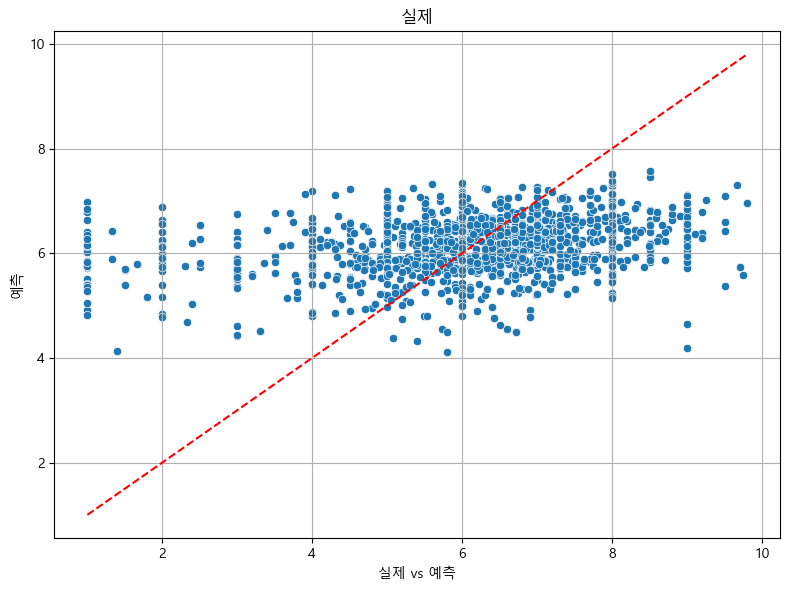

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_valid, y=y_pred)
plt.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], 'r--')
plt.xlabel('실제 vs 예측')
plt.ylabel('예측')
plt.title('실제')
plt.grid(True)
plt.tight_layout()
plt.show()

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Params: {'subsample': 0.6, 'learning_rate': 0.05, 'l2_leaf_reg': 10, 'iterations': 500, 'depth': 6}
Validation RMSE: 1.5565
Validation MAE: 1.1688
Validation R^2: 0.0994


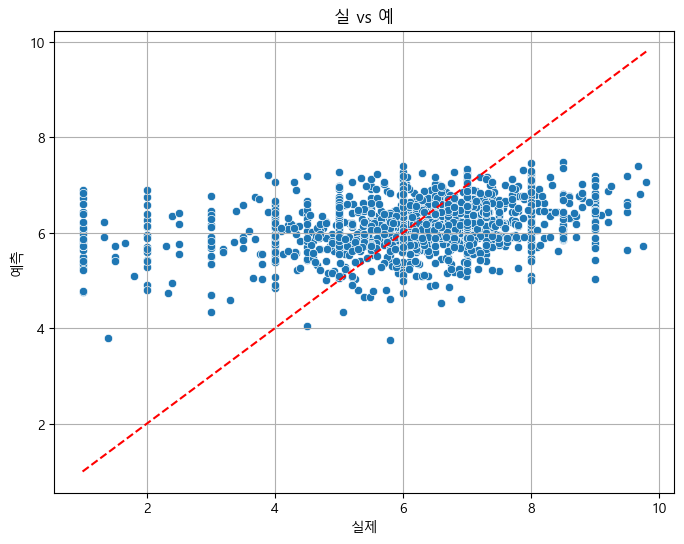

In [30]:
# catboost 모델 튜닝

import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv('tmdb_train_data.csv')
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
df['release_year'] = df['release_year'] - df['release_year'].min()
df['release_month'] = df['release_date'].dt.month
df['release_weekday'] = df['release_date'].dt.weekday

df = df[(df['vote_average'] > 0) & (df['vote_average'] < 10)]

df = df.dropna(subset=['vote_average', 'genres', 'director', 'country'])

df['genres'] = df['genres'].fillna('').apply(lambda x: x.split('|'))
mlb = MultiLabelBinarizer()
genres_encoded = pd.DataFrame(mlb.fit_transform(df['genres']), columns=mlb.classes_, index=df.index)
df = pd.concat([df.drop(columns=['genres']), genres_encoded], axis=1)
df['num_genres'] = df[mlb.classes_].sum(axis=1)

cat_features = ['director', 'country']
for col in cat_features:
    df[col] = df[col].fillna('Unknown')
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

features = ['release_year', 'release_month', 'release_weekday'] + list(mlb.classes_) + cat_features
X = df[features]
y = df['vote_average']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)
cat_features_indices = [X.columns.get_loc(c) for c in cat_features]

model = CatBoostRegressor(verbose=0, random_seed=42)

param_dist = {
    'iterations': [200, 500, 800],
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5, 10],
    'subsample': [0.6, 0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    verbose=2,
    n_jobs=-1
)

random_search.fit(X_train, y_train, cat_features=cat_features_indices)

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_valid)

y_pred_scaled = (y_pred - y_pred.mean()) / y_pred.std() * y_valid.std() + y_valid.mean()

rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
mae = mean_absolute_error(y_valid, y_pred)
r2 = r2_score(y_valid, y_pred)

print("Best Params:", random_search.best_params_)
print(f'Validation RMSE: {rmse:.4f}')
print(f'Validation MAE: {mae:.4f}')
print(f'Validation R^2: {r2:.4f}')

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_valid, y=y_pred)
plt.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], 'r--')
plt.xlabel('실제')
plt.ylabel('예측')
plt.title('실 vs 예')
plt.grid(True)
plt.show()

Fitting 3 folds for each of 20 candidates, totalling 60 fits
0:	learn: 1.6274828	test: 1.6341679	best: 1.6341679 (0)	total: 23.4ms	remaining: 18.7s
100:	learn: 1.5390399	test: 1.5622836	best: 1.5622626 (98)	total: 4.19s	remaining: 29s
200:	learn: 1.5158781	test: 1.5572056	best: 1.5572047 (199)	total: 8.53s	remaining: 25.4s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1.556476884
bestIteration = 231

Shrink model to first 232 iterations.
Best Parameters: {'subsample': 0.6, 'random_strength': 1, 'learning_rate': 0.07, 'l2_leaf_reg': 5, 'iterations': 800, 'depth': 4, 'bagging_temperature': 0.0}
Validation RMSE: 1.5565
Validation MAE: 1.1661
Validation R^2: 0.0994


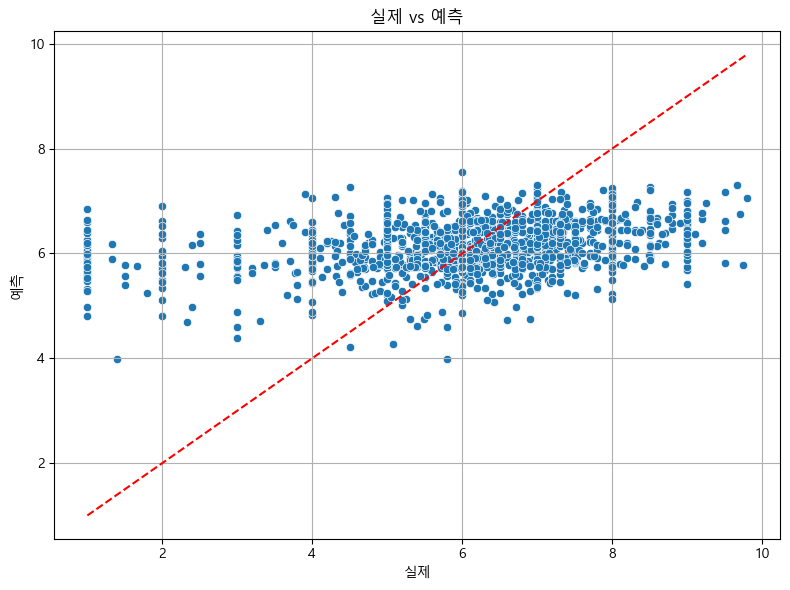

In [40]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv('tmdb_train_data.csv')
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year - df['release_date'].dt.year.min()
df['release_month'] = df['release_date'].dt.month
df['release_weekday'] = df['release_date'].dt.weekday

df = df[(df['vote_average'] > 0) & (df['vote_average'] < 10)]
df = df.dropna(subset=['vote_average', 'genres', 'director', 'country'])

df['genres'] = df['genres'].fillna('').apply(lambda x: x.split('|'))
mlb = MultiLabelBinarizer()
genres_encoded = pd.DataFrame(mlb.fit_transform(df['genres']), columns=mlb.classes_, index=df.index)
df = pd.concat([df.drop(columns=['genres']), genres_encoded], axis=1)
df['num_genres'] = df[mlb.classes_].sum(axis=1)

cat_features = ['director', 'country']
for col in cat_features:
    df[col] = df[col].fillna('Unknown').astype(str)

features = ['release_year', 'release_month', 'release_weekday', 'num_genres'] + list(mlb.classes_) + cat_features
X = df[features]
y = df['vote_average']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)
cat_features_indices = [X.columns.get_loc(c) for c in cat_features]

model = CatBoostRegressor(verbose=0, random_seed=42)

param_dist = {
    'iterations': [500, 800, 1000, 1200, 1500],
    'depth': [4, 6, 8, 10, 12],
    'learning_rate': [0.01, 0.03, 0.05, 0.07, 0.1],
    'l2_leaf_reg': [1, 3, 5, 7, 10, 15],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'bagging_temperature': [0.0, 0.2, 0.5, 1.0],
    'random_strength': [1, 2, 5, 10],
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    verbose=2,
    n_jobs=-1
)

random_search.fit(X_train, y_train, cat_features=cat_features_indices)
best_model = random_search.best_estimator_

best_model.fit(
    X_train, y_train,
    cat_features=cat_features_indices,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=50,
    verbose=100
)

y_pred = best_model.predict(X_valid)

rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
mae = mean_absolute_error(y_valid, y_pred)
r2 = r2_score(y_valid, y_pred)

print("Best Parameters:", random_search.best_params_)
print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation MAE: {mae:.4f}")
print(f"Validation R^2: {r2:.4f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_valid, y=y_pred)
plt.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], 'r--')
plt.xlabel('실제')
plt.ylabel('예측')
plt.title('실제 vs 예측')
plt.grid(True)
plt.tight_layout()
plt.show()

Fitting 3 folds for each of 10 candidates, totalling 30 fits
0:	learn: 1.5347631	test: 1.5407577	best: 1.5407577 (0)	total: 44.9ms	remaining: 22.4s
100:	learn: 0.4218142	test: 0.4180306	best: 0.4180306 (100)	total: 5.29s	remaining: 20.9s
200:	learn: 0.4079484	test: 0.4136136	best: 0.4136060 (198)	total: 11.2s	remaining: 16.7s
300:	learn: 0.3979711	test: 0.4127524	best: 0.4127255 (269)	total: 17.6s	remaining: 11.7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4127254526
bestIteration = 269

Shrink model to first 270 iterations.
Best Parameters: {'subsample': 0.7, 'learning_rate': 0.07, 'l2_leaf_reg': 7, 'iterations': 500, 'depth': 6}
Validation RMSE: 0.4127
Validation MAE: 0.1543
Validation R^2: 0.9367


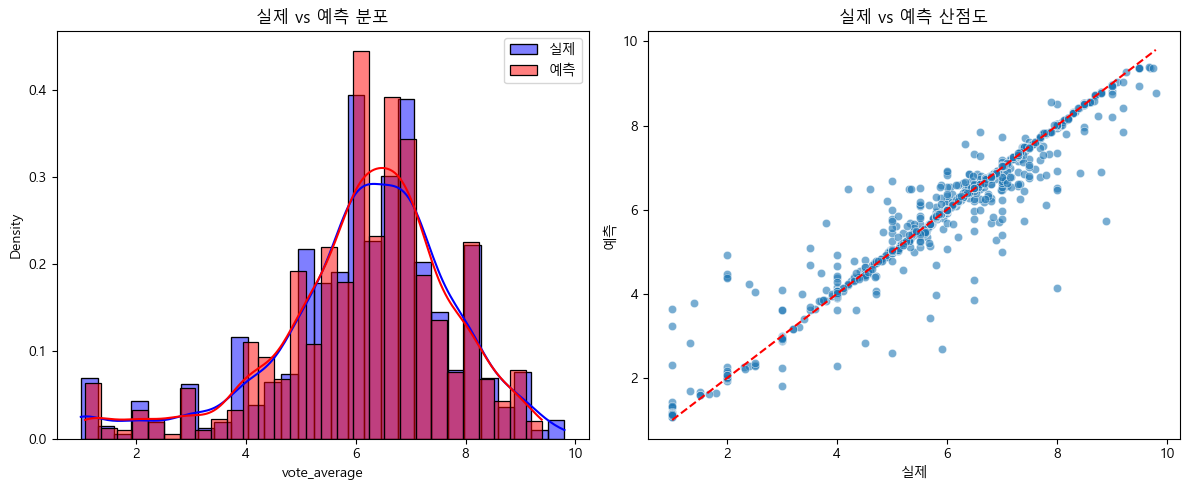

In [42]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv('tmdb_train_data.csv')
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year - df['release_date'].dt.year.min()
df['release_month'] = df['release_date'].dt.month
df['release_weekday'] = df['release_date'].dt.weekday

df = df[(df['vote_average'] > 0) & (df['vote_average'] < 10)]
df = df.dropna(subset=['vote_average', 'genres', 'director', 'country'])

df['genres'] = df['genres'].fillna('').apply(lambda x: x.split('|'))
mlb = MultiLabelBinarizer()
genres_encoded = pd.DataFrame(mlb.fit_transform(df['genres']), columns=mlb.classes_, index=df.index)
df = pd.concat([df.drop(columns=['genres']), genres_encoded], axis=1)
df['num_genres'] = df[mlb.classes_].sum(axis=1)

cat_features = ['director', 'country']
for col in cat_features:
    df[col] = df[col].fillna('Unknown').astype(str)

df['director_mean_vote'] = df.groupby('director')['vote_average'].transform('mean')
df['country_mean_vote'] = df.groupby('country')['vote_average'].transform('mean')

features = ['release_year', 'release_month', 'release_weekday', 'num_genres'] + \
           list(mlb.classes_) + cat_features + ['director_mean_vote', 'country_mean_vote']
X = df[features]
y = df['vote_average']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)
cat_features_indices = [X.columns.get_loc(c) for c in cat_features]

model = CatBoostRegressor(
    verbose=0,
    random_seed=42,
    loss_function='RMSE'
)

param_dist = {
    'iterations': [500, 700, 1000],
    'depth': [6, 8, 10],
    'learning_rate': [0.03, 0.05, 0.07],
    'l2_leaf_reg': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    verbose=2,
    n_jobs=-1
)

random_search.fit(X_train, y_train, cat_features=cat_features_indices)
best_model = random_search.best_estimator_

best_model.fit(
    X_train, y_train,
    cat_features=cat_features_indices,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=50,
    verbose=100
)

y_pred = best_model.predict(X_valid)

rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
mae = mean_absolute_error(y_valid, y_pred)
r2 = r2_score(y_valid, y_pred)

print("Best Parameters:", random_search.best_params_)
print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation MAE: {mae:.4f}")
print(f"Validation R^2: {r2:.4f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(y_valid, color='blue', label='실제', kde=True, stat="density")
sns.histplot(y_pred, color='red', label='예측', kde=True, stat="density")
plt.legend()
plt.title('실제 vs 예측 분포')

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_valid, y=y_pred, alpha=0.6)
plt.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], 'r--')
plt.xlabel('실제')
plt.ylabel('예측')
plt.title('실제 vs 예측 산점도')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from catboost import Pool

test_df = pd.read_csv('test_data.csv')

test_df['release_date'] = pd.to_datetime(test_df['개봉일'], errors='coerce')
train_min_year = df['release_date'].dt.year.min()
test_df['release_year'] = test_df['release_date'].dt.year - train_min_year
test_df['release_month'] = test_df['release_date'].dt.month
test_df['release_weekday'] = test_df['release_date'].dt.weekday

test_df['genres'] = test_df['장르'].fillna('').apply(lambda x: x.split('|'))

genres_encoded_test = pd.DataFrame(mlb.transform(test_df['genres']),
                                   columns=mlb.classes_,
                                   index=test_df.index)

test_df['num_genres'] = genres_encoded_test.sum(axis=1)

test_df['director'] = test_df['감독'].fillna('Unknown').astype(str)
test_df.loc[~test_df['director'].isin(df['director'].unique()), 'director'] = 'Unknown'

test_df['country'] = test_df['제작국가'].fillna('Unknown').astype(str)
test_df.loc[~test_df['country'].isin(df['country'].unique()), 'country'] = 'Unknown'

director_mean_map = df.groupby('director')['vote_average'].mean()
country_mean_map = df.groupby('country')['vote_average'].mean()

test_df['director_mean_vote'] = test_df['director'].map(director_mean_map).fillna(df['vote_average'].mean())
test_df['country_mean_vote'] = test_df['country'].map(country_mean_map).fillna(df['vote_average'].mean())

X_test = pd.concat([
    test_df[['release_year', 'release_month', 'release_weekday', 'num_genres']],
    genres_encoded_test,
    test_df[['director', 'country', 'director_mean_vote', 'country_mean_vote']]
], axis=1)

cat_features_test = [X_test.columns.get_loc(col) for col in ['director', 'country']]

test_pool = Pool(data=X_test, cat_features=cat_features_test)
y_test_pred = best_model.predict(test_pool)

submission = pd.DataFrame({
    '영화명': test_df['영화명'],
    '예측_평점': y_test_pred
})

print(submission.head())



        영화명     예측_평점
0    태양의 노래  6.216573
1       좀비딸  6.215546
2      바이러스  6.217338
3  우리 둘 사이에  6.215546
4    엣 더 벤치  6.215546


In [58]:
submission

,영화명,예측_평점
0,태양의 노래,6.216573
1,좀비딸,6.215546
2,바이러스,6.217338
3,우리 둘 사이에,6.215546
4,엣 더 벤치,6.215546
...,...,...
3904,디어스킨,6.218085
3905,타발루가와 얼음공주,6.218085
3906,닥터 두리틀,6.218085
3907,스타워즈: 라이즈 오브 스카이워커,6.218085


In [ ]:
print(test_df['director_mean_vote'].isna().sum())
print(test_df['director_mean_vote'].value_counts())
print(test_df['country_mean_vote'].value_counts())

0
director_mean_vote
6.162897    3909
Name: count, dtype: int64
country_mean_vote
6.162897    3909
Name: count, dtype: int64


Fitting 3 folds for each of 10 candidates, totalling 30 fits
0:	learn: 1.6196141	test: 1.6536664	best: 1.6536664 (0)	total: 72.9ms	remaining: 36.4s
100:	learn: 1.4545074	test: 1.5091215	best: 1.5090868 (97)	total: 6.49s	remaining: 25.6s
200:	learn: 1.4237975	test: 1.4990187	best: 1.4988029 (195)	total: 11.3s	remaining: 16.9s
300:	learn: 1.4045048	test: 1.4953967	best: 1.4953967 (300)	total: 16.3s	remaining: 10.8s
400:	learn: 1.3887508	test: 1.4927763	best: 1.4925636 (385)	total: 23.1s	remaining: 5.71s
499:	learn: 1.3734933	test: 1.4926611	best: 1.4921326 (467)	total: 30.7s	remaining: 0us

bestTest = 1.492132609
bestIteration = 467

Shrink model to first 468 iterations.
Best Parameters: {'subsample': 0.7, 'learning_rate': 0.07, 'l2_leaf_reg': 7, 'iterations': 500, 'depth': 6}
Validation RMSE: 1.4921
Validation MAE: 1.0929
Validation R^2: 0.1967


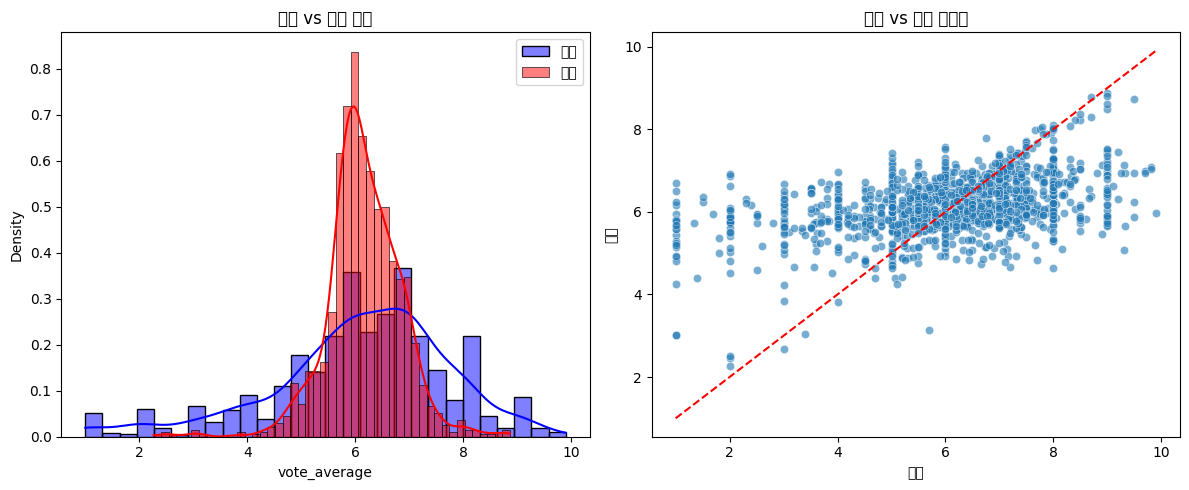

In [2]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv('tmdb_train_data.csv')
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year - df['release_date'].dt.year.min()
df['release_month'] = df['release_date'].dt.month
df['release_weekday'] = df['release_date'].dt.weekday

df = df[(df['vote_average'] > 0) & (df['vote_average'] < 10)]
df = df.dropna(subset=['vote_average', 'genres', 'country'])

df['genres'] = df['genres'].fillna('').apply(lambda x: x.split('|'))
mlb = MultiLabelBinarizer()
genres_encoded = pd.DataFrame(mlb.fit_transform(df['genres']), columns=mlb.classes_, index=df.index)
df = pd.concat([df.drop(columns=['genres']), genres_encoded], axis=1)
df['num_genres'] = df[mlb.classes_].sum(axis=1)

cat_features = ['country']
for col in cat_features:
    df[col] = df[col].fillna('Unknown').astype(str)

df['country_mean_vote'] = df.groupby('country')['vote_average'].transform('mean')

features = ['release_year', 'release_month', 'release_weekday', 'num_genres'] + \
           list(mlb.classes_) + cat_features + ['country_mean_vote']
X = df[features]
y = df['vote_average']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)
cat_features_indices = [X.columns.get_loc(c) for c in cat_features]

model = CatBoostRegressor(
    verbose=0,
    random_seed=42,
    loss_function='RMSE'
)

param_dist = {
    'iterations': [500, 700, 1000],
    'depth': [6, 8, 10],
    'learning_rate': [0.03, 0.05, 0.07],
    'l2_leaf_reg': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    verbose=2,
    n_jobs=-1
)

random_search.fit(X_train, y_train, cat_features=cat_features_indices)
best_model = random_search.best_estimator_

best_model.fit(
    X_train, y_train,
    cat_features=cat_features_indices,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=50,
    verbose=100
)

y_pred = best_model.predict(X_valid)

rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
mae = mean_absolute_error(y_valid, y_pred)
r2 = r2_score(y_valid, y_pred)

print("Best Parameters:", random_search.best_params_)
print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation MAE: {mae:.4f}")
print(f"Validation R^2: {r2:.4f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(y_valid, color='blue', label='실제', kde=True, stat="density")
sns.histplot(y_pred, color='red', label='예측', kde=True, stat="density")
plt.legend()
plt.title('실제 vs 예측 분포')

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_valid, y=y_pred, alpha=0.6)
plt.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], 'r--')
plt.xlabel('실제')
plt.ylabel('예측')
plt.title('실제 vs 예측 산점도')

plt.tight_layout()
plt.show()

[분류모델]

Fitting 3 folds for each of 10 candidates, totalling 30 fits
0:	learn: 1.9785321	test: 1.9769429	best: 1.9769429 (0)	total: 712ms	remaining: 8m 17s
100:	learn: 0.3397917	test: 0.4095011	best: 0.4095011 (100)	total: 1m	remaining: 5m 59s
200:	learn: 0.2716238	test: 0.3764831	best: 0.3764831 (200)	total: 2m 9s	remaining: 5m 22s
300:	learn: 0.2583340	test: 0.3711935	best: 0.3711711 (297)	total: 3m 21s	remaining: 4m 27s
400:	learn: 0.2421830	test: 0.3668596	best: 0.3668370 (398)	total: 4m 33s	remaining: 3m 23s
500:	learn: 0.2269724	test: 0.3641183	best: 0.3640427 (496)	total: 5m 46s	remaining: 2m 17s
600:	learn: 0.2148122	test: 0.3625183	best: 0.3624946 (598)	total: 6m 59s	remaining: 1m 9s
699:	learn: 0.2013721	test: 0.3611028	best: 0.3610770 (674)	total: 8m 12s	remaining: 0us

bestTest = 0.361076981
bestIteration = 674

Shrink model to first 675 iterations.
Best Parameters: {'subsample': 0.8, 'learning_rate': 0.07, 'l2_leaf_reg': 5, 'iterations': 700, 'depth': 10, 'bootstrap_type': 'Bernou

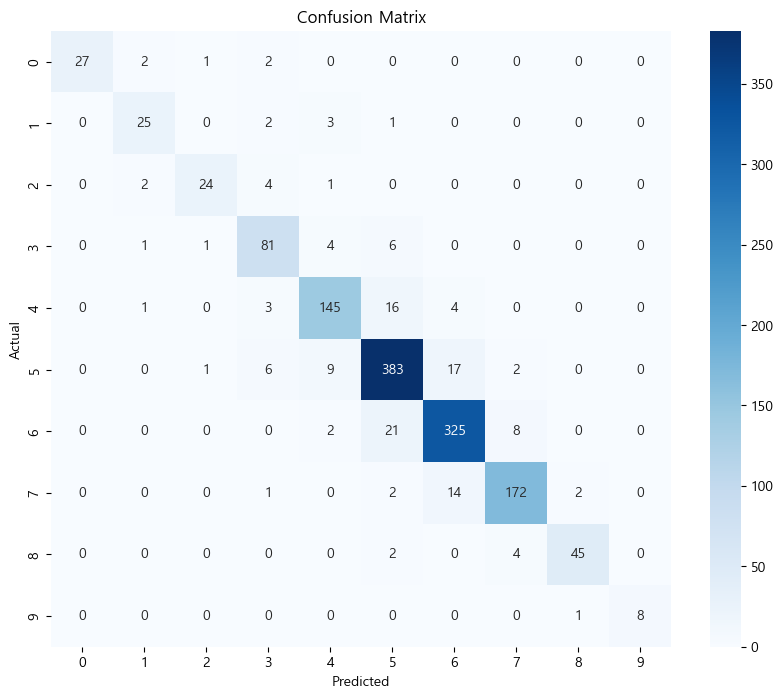

In [4]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import matplotlib
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import seaborn as sns

font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = fm.FontProperties(fname=font_path).get_name()
matplotlib.rc('font', family=font_name)

warnings.filterwarnings("ignore")

df = pd.read_csv('tmdb_train_data.csv')
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year - df['release_date'].dt.year.min()
df['release_month'] = df['release_date'].dt.month
df['release_weekday'] = df['release_date'].dt.weekday

df = df[(df['vote_average'] > 0) & (df['vote_average'] < 10)]
df = df.dropna(subset=['vote_average', 'genres', 'director', 'country'])

df['vote_class'] = df['vote_average'].round().astype(int)

df['genres'] = df['genres'].fillna('').apply(lambda x: x.split('|'))
mlb = MultiLabelBinarizer()
genres_encoded = pd.DataFrame(mlb.fit_transform(df['genres']), columns=mlb.classes_, index=df.index)
df = pd.concat([df.drop(columns=['genres']), genres_encoded], axis=1)
df['num_genres'] = df[mlb.classes_].sum(axis=1)

cat_features = ['director', 'country']
for col in cat_features:
    df[col] = df[col].fillna('Unknown').astype(str)

df['director_mean_vote'] = df.groupby('director')['vote_average'].transform('mean')
df['country_mean_vote'] = df.groupby('country')['vote_average'].transform('mean')

features = ['release_year', 'release_month', 'release_weekday', 'num_genres'] + \
           list(mlb.classes_) + cat_features + ['director_mean_vote', 'country_mean_vote']

X = df[features]
y = df['vote_class']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)
cat_features_indices = [X.columns.get_loc(c) for c in cat_features]

model = CatBoostClassifier(
    verbose=0,
    random_seed=42,
    loss_function='MultiClass'
)

param_dist = {
    'iterations': [500, 700, 1000],
    'depth': [6, 8, 10],
    'learning_rate': [0.03, 0.05, 0.07],
    'l2_leaf_reg': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'bootstrap_type': ['Poisson', 'Bernoulli']
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,
    scoring='accuracy',
    cv=3,
    random_state=42,
    verbose=2,
    n_jobs=-1
)

random_search.fit(X_train, y_train, cat_features=cat_features_indices)
best_model = random_search.best_estimator_

best_model.fit(
    X_train, y_train,
    cat_features=cat_features_indices,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=50,
    verbose=100
)

y_pred = best_model.predict(X_valid)
accuracy = accuracy_score(y_valid, y_pred)
print("Best Parameters:", random_search.best_params_)
print(f"Validation Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_valid, y_pred))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_valid, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Fitting 2 folds for each of 5 candidates, totalling 10 fits
[CV] END bootstrap_type=No, depth=6, iterations=400, l2_leaf_reg=3, learning_rate=0.03; total time=  20.5s
[CV] END bootstrap_type=No, depth=6, iterations=400, l2_leaf_reg=3, learning_rate=0.03; total time=  23.8s
[CV] END bootstrap_type=Poisson, depth=8, iterations=300, l2_leaf_reg=5, learning_rate=0.03; total time=   0.0s
[CV] END bootstrap_type=Poisson, depth=8, iterations=300, l2_leaf_reg=5, learning_rate=0.03; total time=   0.0s
[CV] END bootstrap_type=No, depth=7, iterations=400, l2_leaf_reg=5, learning_rate=0.03; total time=  28.4s
[CV] END bootstrap_type=No, depth=7, iterations=400, l2_leaf_reg=5, learning_rate=0.03; total time=  27.4s
[CV] END bootstrap_type=No, depth=6, iterations=300, l2_leaf_reg=3, learning_rate=0.03; total time=  16.8s
[CV] END bootstrap_type=No, depth=6, iterations=300, l2_leaf_reg=3, learning_rate=0.03; total time=  16.8s
[CV] END bootstrap_type=No, depth=8, iterations=400, l2_leaf_reg=3, learni

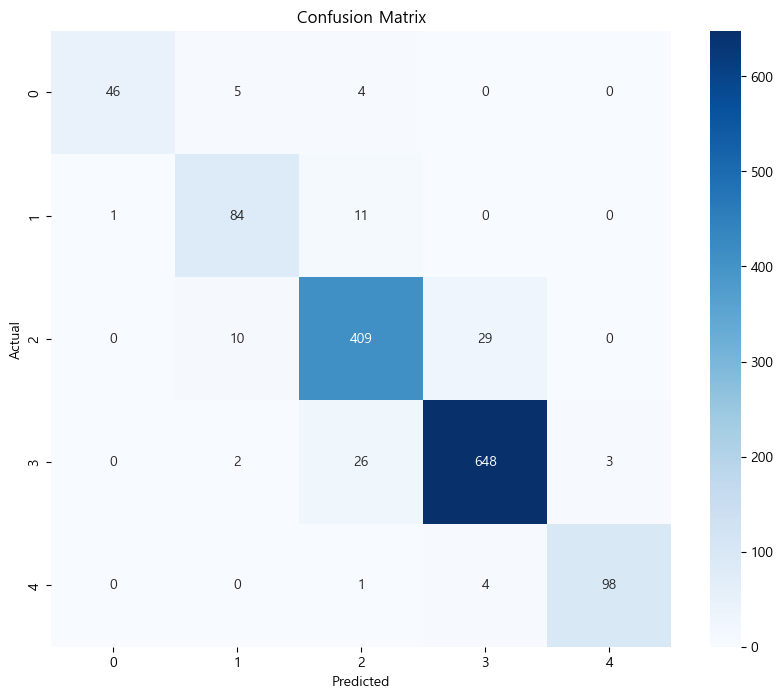

In [39]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import matplotlib.font_manager as fm
import matplotlib

font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = fm.FontProperties(fname=font_path).get_name()
matplotlib.rc('font', family=font_name)

warnings.filterwarnings("ignore")

df = pd.read_csv('tmdb_train_data.csv')
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year - df['release_date'].dt.year.min()
df['release_month'] = df['release_date'].dt.month
df['release_weekday'] = df['release_date'].dt.weekday

df = df[(df['vote_average'] > 0) & (df['vote_average'] < 10)]
df = df.dropna(subset=['vote_average', 'genres', 'director', 'country'])

df['vote_class'] = np.ceil(df['vote_average']).astype(int)
df.loc[df['vote_class'] > 10, 'vote_class'] = 10

def convert_10_to_5(v):
    if v in [1, 2]:
        return 1
    elif v in [3, 4]:
        return 2
    elif v in [5, 6]:
        return 3
    elif v in [7, 8]:
        return 4
    else:
        return 5

df['vote_class_5'] = df['vote_class'].apply(convert_10_to_5)

df['genres'] = df['genres'].fillna('').apply(lambda x: x.split('|'))
mlb = MultiLabelBinarizer()
genres_encoded = pd.DataFrame(mlb.fit_transform(df['genres']), columns=mlb.classes_, index=df.index)
df = pd.concat([df.drop(columns=['genres']), genres_encoded], axis=1)
df['num_genres'] = genres_encoded.sum(axis=1)

cat_features = ['director', 'country']
for col in cat_features:
    df[col] = df[col].fillna('Unknown').astype(str)

df['director_mean_vote'] = df.groupby('director')['vote_average'].transform('mean')
df['country_mean_vote'] = df.groupby('country')['vote_average'].transform('mean')

features = ['release_year', 'release_month', 'release_weekday', 'num_genres'] + \
           list(mlb.classes_) + cat_features + ['director_mean_vote', 'country_mean_vote']

X = df[features]
y = df['vote_class_5']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

cat_features_indices = [X.columns.get_loc(c) for c in cat_features]

model = CatBoostClassifier(
    verbose=0,
    random_seed=42,
    loss_function='MultiClass'
)

param_dist = {
    'iterations': [300, 400, 500],
    'depth': [6, 7, 8],
    'learning_rate': [0.03, 0.05],
    'l2_leaf_reg': [3, 5],
    'bootstrap_type': ['No', 'Poisson'],
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=5,
    scoring='accuracy',
    cv=2,
    random_state=42,
    verbose=2,
    n_jobs=1
)

random_search.fit(X_train, y_train, cat_features=cat_features_indices)

best_model = random_search.best_estimator_

best_model.fit(
    X_train, y_train,
    cat_features=cat_features_indices,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=50,
    verbose=100
)

y_pred = best_model.predict(X_valid)
accuracy = accuracy_score(y_valid, y_pred)
print("Best Parameters:", random_search.best_params_)
print(f"Validation Accuracy: {accuracy:.4f}\n")
print("Classification Report:")
print(classification_report(y_valid, y_pred))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_valid, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


0:	learn: 1.7956176	test: 1.7943047	best: 1.7943047 (0)	total: 235ms	remaining: 1m 10s
100:	learn: 0.3575451	test: 0.3767552	best: 0.3767552 (100)	total: 9.36s	remaining: 18.4s
200:	learn: 0.3152746	test: 0.3568967	best: 0.3568434 (198)	total: 18s	remaining: 8.86s
299:	learn: 0.2922126	test: 0.3489933	best: 0.3486544 (295)	total: 26.2s	remaining: 0us

bestTest = 0.3486543971
bestIteration = 295

Shrink model to first 296 iterations.

Validation Accuracy: 0.8979

Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.81      0.90        32
           2       0.81      0.81      0.81        31
           3       0.80      0.77      0.79        31
           4       0.84      0.87      0.86        93
           5       0.89      0.86      0.88       169
           6       0.88      0.92      0.90       418
           7       0.91      0.92      0.91       356
           8       0.95      0.91      0.93       191
           9       0.94

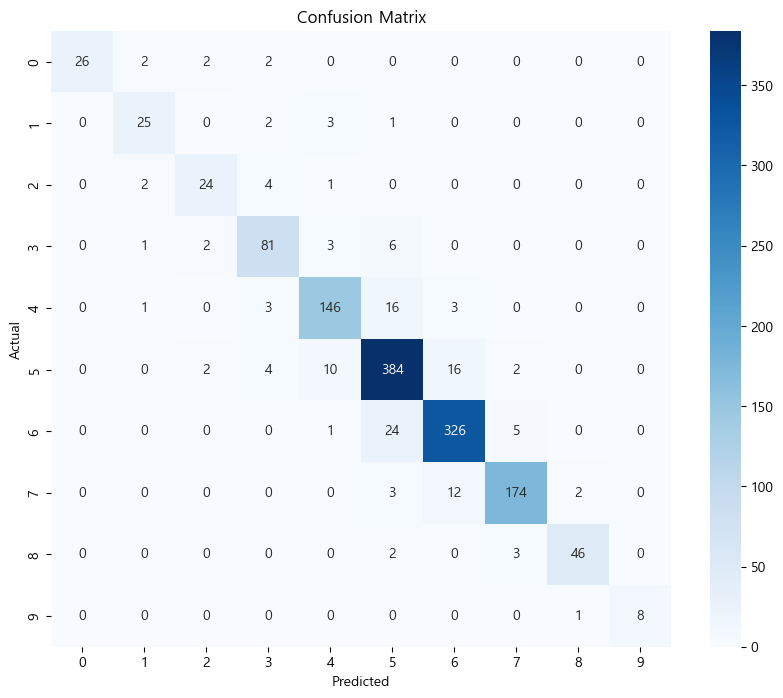

In [ ]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import matplotlib.font_manager as fm
import warnings

font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = fm.FontProperties(fname=font_path).get_name()
matplotlib.rc('font', family=font_name)

warnings.filterwarnings("ignore")

df = pd.read_csv('tmdb_train_data.csv')
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year - df['release_date'].dt.year.min()
df['release_month'] = df['release_date'].dt.month
df['release_weekday'] = df['release_date'].dt.weekday

df = df[(df['vote_average'] > 0) & (df['vote_average'] < 10)]
df = df.dropna(subset=['vote_average', 'genres', 'director', 'country'])

df['vote_class'] = df['vote_average'].round().astype(int)

df['main_genre'] = df['genres'].apply(lambda x: x.split('|')[0] if pd.notnull(x) and '|' in x else x)

df['main_genre'] = df['main_genre'].fillna('Unknown')
df = pd.get_dummies(df, columns=['main_genre'], prefix='genre')

cat_features = ['director', 'country']
for col in cat_features:
    df[col] = df[col].fillna('Unknown').astype(str)

df['director_mean_vote'] = df.groupby('director')['vote_average'].transform('mean')
df['country_mean_vote'] = df.groupby('country')['vote_average'].transform('mean')

features = ['release_year', 'release_month', 'release_weekday'] + \
           list(df.columns[df.columns.str.startswith('genre_')]) + \
           cat_features + ['director_mean_vote', 'country_mean_vote']

X = df[features]
y = df['vote_class']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)
cat_features_indices = [X.columns.get_loc(c) for c in cat_features]

model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    l2_leaf_reg=3,
    loss_function='MultiClass',
    verbose=100,
    random_seed=42
)

model.fit(
    X_train, y_train,
    cat_features=cat_features_indices,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=30
)

y_pred = model.predict(X_valid)
accuracy = accuracy_score(y_valid, y_pred)
print(f"\nValidation Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_valid, y_pred))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_valid, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


폰트 설정 완료: Malgun Gothic
--- 훈련 데이터 로드 및 전처리 시작 ---
--- 훈련 데이터 전처리 완료 ---
X_train shape: (5521, 1163)
X_valid shape: (1381, 1163)

--- CatBoost 모델 학습 시작 ---
0:	learn: 2.1030607	test: 2.1018921	best: 2.1018921 (0)	total: 141ms	remaining: 2m 21s
100:	learn: 0.3925860	test: 0.4370568	best: 0.4370568 (100)	total: 16.8s	remaining: 2m 29s
200:	learn: 0.3357966	test: 0.3911741	best: 0.3911741 (200)	total: 38.3s	remaining: 2m 32s
300:	learn: 0.3180889	test: 0.3812167	best: 0.3811698 (299)	total: 1m 1s	remaining: 2m 21s
400:	learn: 0.3091784	test: 0.3786789	best: 0.3786789 (400)	total: 1m 23s	remaining: 2m 4s
500:	learn: 0.2988613	test: 0.3750269	best: 0.3750257 (499)	total: 1m 46s	remaining: 1m 45s
600:	learn: 0.2902945	test: 0.3720980	best: 0.3719462 (596)	total: 2m 9s	remaining: 1m 26s
700:	learn: 0.2817243	test: 0.3690445	best: 0.3690411 (695)	total: 2m 32s	remaining: 1m 5s
800:	learn: 0.2742509	test: 0.3674201	best: 0.3673614 (796)	total: 2m 49s	remaining: 42.1s
900:	learn: 0.2686589	test: 

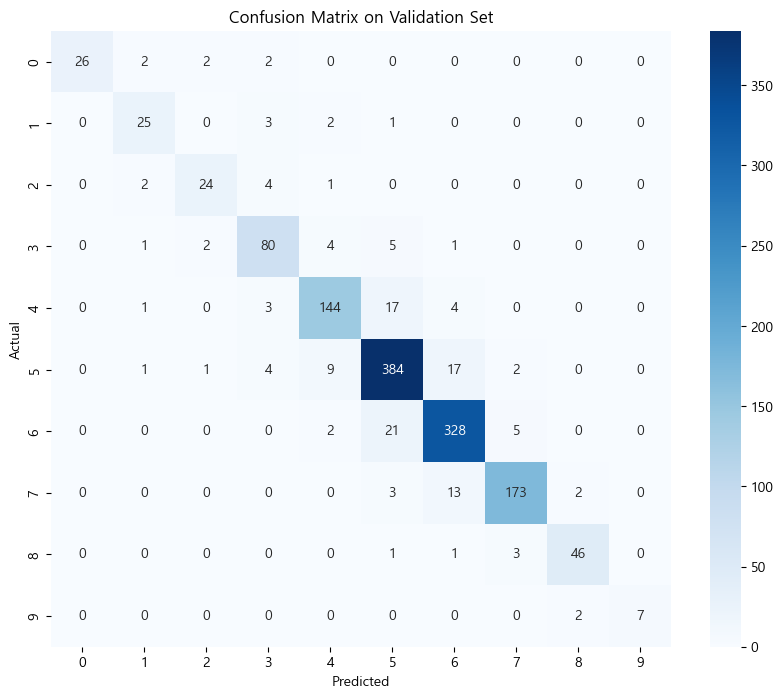


--- 테스트 데이터 로드 및 전처리 시작 ---

--- 매핑되지 않은 감독 이름을 찾습니다 (수동 추가 필요) ---
--- 테스트 데이터 전처리 완료 ---
X_test shape: (3909, 1163)

--- X_train과 X_test 컬럼 일치 여부 최종 확인 ---
컬럼 집합 일치 여부 (이름만, 순서 무관): True
컬럼 이름 및 순서 정확히 일치 여부: True

X_train과 X_test의 컬럼 이름과 순서가 완벽하게 일치


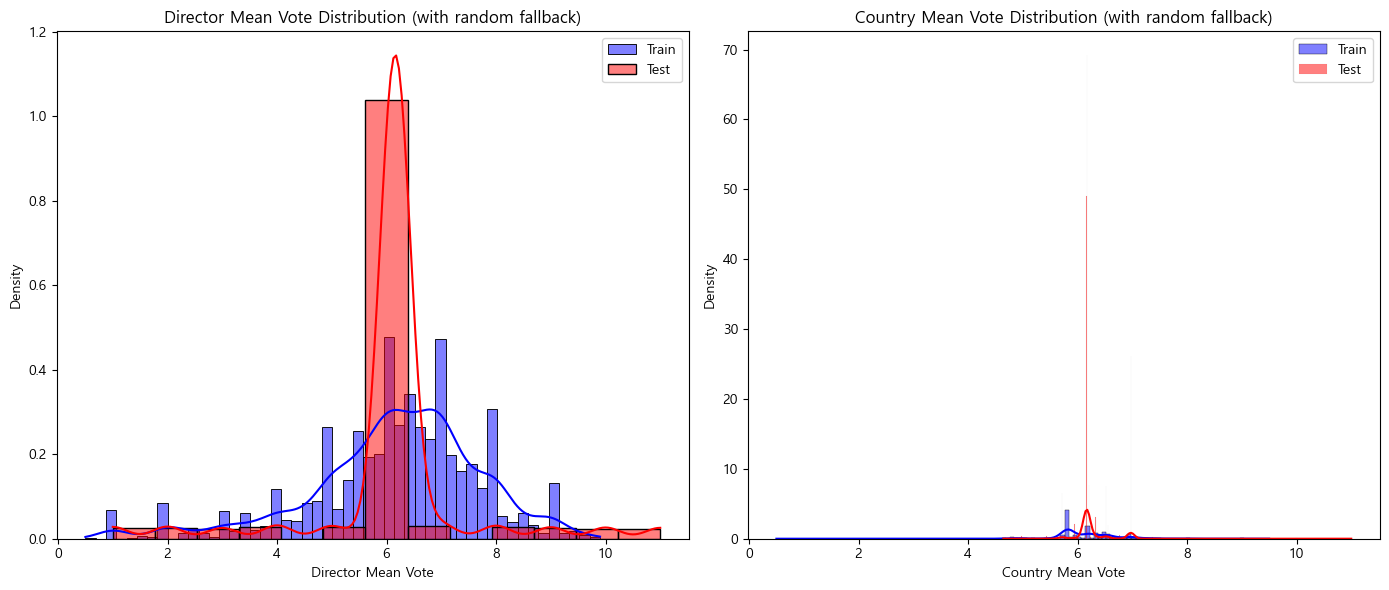


--- 테스트 데이터 예측 시작 ---

Test Set Predictions (Vote Classes):
[6 6 6 ... 6 6 6]
--- 예측 완료 ---

--- 예측 결과를 원본 df_test에 '평점' 컬럼으로 추가 ---
      title  평점   director      country  genres
0    태양의 노래   6        조영준  South Korea   Drama
1       좀비딸   6        필감성  South Korea  Comedy
2      바이러스   6        강이관  South Korea   Drama
3  우리 둘 사이에   6        성지혜  South Korea   Drama
4    엣 더 벤치   6  오쿠야마 요시유키        Japan   Drama

업데이트된 df_test의 shape: (3909, 14)


In [35]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import matplotlib.font_manager as fm
import warnings
import random

warnings.filterwarnings("ignore")

font_path = "C:/Windows/Fonts/malgun.ttf"
try:
    font_name = fm.FontProperties(fname=font_path).get_name()
    matplotlib.rc('font', family=font_name)
    print(f"폰트 설정 완료: {font_name}")
except Exception as e:
    print(f"폰트 설정 실패: {e}. 기본 폰트로 진행합니다.")


print("--- 훈련 데이터 로드 및 전처리 시작 ---")
df = pd.read_csv('tmdb_train_data.csv')

df.rename(columns={
    '영화명': 'title',
    '감독': 'director',
    '제작국가': 'country',
    '개봉일': 'release_date',
    '장르': 'genres',
    '평점': 'vote_average'
}, inplace=True)

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

min_year = df['release_date'].dt.year.min()
df['release_year'] = df['release_date'].dt.year - min_year
df['release_month'] = df['release_date'].dt.month
df['release_weekday'] = df['release_date'].dt.weekday

df = df[(df['vote_average'] > 0) & (df['vote_average'] < 10)]
df = df.dropna(subset=['vote_average', 'genres', 'director', 'country'])

df['vote_class'] = df['vote_average'].round().astype(int)

df['main_genre'] = df['genres'].apply(lambda x: x.split('|')[0] if pd.notnull(x) and '|' in x else x)
df['main_genre'] = df['main_genre'].fillna('Unknown')

df = pd.get_dummies(df, columns=['main_genre'], prefix='genre')

cat_features = ['director', 'country']
for col in cat_features:
    df[col] = df[col].fillna('Unknown').astype(str)

director_mean_vote_train_map = df.groupby('director')['vote_average'].mean()
country_mean_vote_train_map = df.groupby('country')['vote_average'].mean()
overall_mean_vote_train = df['vote_average'].mean()

df['director_mean_vote'] = df['director'].map(director_mean_vote_train_map).fillna(overall_mean_vote_train)
df['country_mean_vote'] = df['country'].map(country_mean_vote_train_map).fillna(overall_mean_vote_train)


features = ['release_year', 'release_month', 'release_weekday'] + \
           list(df.columns[df.columns.str.startswith('genre_')]) + \
           cat_features + ['director_mean_vote', 'country_mean_vote']

X = df[features]
y = df['vote_class']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

cat_features_indices_train = [X_train.columns.get_loc(c) for c in cat_features]

print("--- 훈련 데이터 전처리 완료 ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_valid shape: {X_valid.shape}")


print("\n--- CatBoost 모델 학습 시작 ---")
model = CatBoostClassifier(
    iterations=1000,
    depth=7,
    learning_rate=0.05,
    l2_leaf_reg=5,
    loss_function='MultiClass',
    verbose=100,
    random_seed=42,
    early_stopping_rounds=100
)

model.fit(
    X_train, y_train,
    cat_features=cat_features_indices_train,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=100
)
print("--- CatBoost 모델 학습 완료 ---")

y_pred = model.predict(X_valid)
accuracy = accuracy_score(y_valid, y_pred)
print(f"\nValidation Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_valid, y_pred))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_valid, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix on Validation Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


print("\n--- 테스트 데이터 로드 및 전처리 시작 ---")
df_test = pd.read_csv('test_data.csv')

df_test.rename(columns={
    '영화명': 'title',
    '감독': 'director',
    '제작국가': 'country',
    '개봉일': 'release_date',
    '장르': 'genres'
}, inplace=True)


df_test['release_date'] = pd.to_datetime(df_test['release_date'], errors='coerce')

df_test['release_year'] = df_test['release_date'].dt.year - min_year
df_test['release_month'] = df_test['release_date'].dt.month
df_test['release_weekday'] = df_test['release_date'].dt.weekday

def get_random_vote():
    return random.randint(1, 11)

def translate_composite_names_with_random_fallback(name_str, mapping_dict, separator='|', secondary_separator=','):
    if pd.isnull(name_str):
        return 'Unknown_Random' 
    
    translated_parts = []
    parts = str(name_str).split(separator)
    if len(parts) == 1 and secondary_separator in parts[0]: 
        parts = parts[0].split(secondary_separator)
    
    for part in parts:
        p_stripped = part.strip()
        translated_parts.append(mapping_dict.get(p_stripped, 'Unknown_Random')) 
    return (separator if separator == '|' else ', ').join(translated_parts)

country_mapping = {
    '대한민국': 'South Korea', '한국': 'South Korea',
    '미국': 'United States', '일본': 'Japan', '영국': 'United Kingdom',
    '프랑스': 'France', '독일': 'Germany', '중국': 'China', '캐나다': 'Canada',
    '인도': 'India', '스페인': 'Spain', '이탈리아': 'Italy', '러시아': 'Russia',
    '호주': 'Australia', '멕시코': 'Mexico', '스웨덴': 'Sweden', '덴마크': 'Denmark',
    '노르웨이': 'Norway', '핀란드': 'Finland', '벨기에': 'Belgium', '네덜란드': 'Netherlands',
    '아일랜드': 'Ireland', '뉴질랜드': 'New Zealand', '브라질': 'Brazil', '아르헨티나': 'Argentina',
    '남아프리카 공화국': 'South Africa', '홍콩': 'Hong Kong', '대만': 'Taiwan',
    '체코': 'Czech Republic', '폴란드': 'Poland', '오스트리아': 'Austria',
    '스위스': 'Switzerland', '그리스': 'Greece', '포르투갈': 'Portugal',
    '튀르키예': 'Turkey', '터키': 'Turkey',
    '이스라엘': 'Israel', '이란': 'Iran', '이집트': 'Egypt',
    '콜롬비아': 'Colombia', '태국': 'Thailand', '필리핀': 'Philippines',
    '인도네시아': 'Indonesia', '베트남': 'Vietnam', '싱가포르': 'Singapore',
    '아랍에미리트': 'United Arab Emirates', '사우디아라비아': 'Saudi Arabia',
    '아이슬란드': 'Iceland', '헝가리': 'Hungary', '루마니아': 'Romania',
    '불가리아': 'Bulgaria', '크로아티아': 'Croatia', '세르비아': 'Serbia',
    '슬로베니아': 'Slovenia', '슬로바키아': 'Slovakia', '에스토니아': 'Estonia',
    '라트비아': 'Latvia', '리투아니아': 'Lithuania', '우크라이나': 'Ukraine',
    '아제르바이잔': 'Azerbaijan', '카자흐스탄': 'Kazakhstan', '우즈베키스탄': 'Uzbekistan',
    '조지아': 'Georgia', '아르메니아': 'Armenia', '벨라루스': 'Belarus',
    '에티오피아': 'Ethiopia', '케냐': 'Kenya', '나이지리아': 'Nigeria', '모로코': 'Morocco',
    '튀니지': 'Tunisia', '알제리': 'Algeria', '레바논': 'Lebanon', '요르단': 'Jordan',
    '시리아': 'Syria', '이라크': 'Iraq', '예멘': 'Yemen', '아프가니스탄': 'Afghanistan',
    '파키스탄': 'Pakistan', '방글라데시': 'Bangladesh', '스리랑카': 'Sri Lanka',
    '네팔': 'Nepal', '부탄': 'Bhutan', '몽골': 'Mongolia', '쿠바': 'Cuba',
    '도미니카 공화국': 'Dominican Republic', '자메이카': 'Jamaica', '트리니다드 토바고': 'Trinidad and Tobago',
    '바하마': 'Bahamas', '바베이도스': 'Barbados', '도미니카': 'Dominica',
    '세인트루시아': 'Saint Lucia', '세인트빈센트 그레나딘': 'Saint Vincent and the Grenadines',
    '그레나다': 'Grenada', '앤티가 바부다': 'Antigua and Barbuda', '벨리즈': 'Belize',
    '코스타리카': 'Costa Rica', '엘살바도르': 'El Salvador', '과테말라': 'Guatemala',
    '온두라스': 'Honduras', '니카라과': 'Nicaragua', '파나마': 'Panama',
    '우루과이': 'Uruguay', '파라과이': 'Paraguay',
    '덴마크령': 'Denmark',
    '오스트리아 ,영국': 'Austria, United Kingdom',
    '기타': 'Unknown',
    np.nan: 'Unknown', '': 'Unknown'
}
df_test['country'] = df_test['country'].apply(lambda x: translate_composite_names_with_random_fallback(x, country_mapping, separator=',', secondary_separator=','))
df_test['country'] = df_test['country'].astype(str).replace(r'^[가-힣\s,]+$', 'Unknown', regex=True)


genre_mapping = {
    '드라마': 'Drama', '액션': 'Action', '코미디': 'Comedy', '스릴러': 'Thriller',
    '범죄': 'Crime', '판타지': 'Fantasy', 'SF': 'Science Fiction', '모험': 'Adventure',
    '애니메이션': 'Animation', '가족': 'Family', '공포': 'Horror', '미스터리': 'Mystery',
    '로맨스': 'Romance', '역사': 'History', '전쟁': 'War', '음악': 'Music',
    '다큐멘터리': 'Documentary', '서부': 'Western', 'TV 영화': 'TV Movie',
    '공포(호러)': 'Horror',
    '공연': 'Concert', '스포츠': 'Sport', '성인': 'Adult', '실험': 'Experimental',
    '컬트': 'Cult', '느와르': 'Noir', '뮤지컬': 'Musical',
    '다큐': 'Documentary', '사극': 'Historical Drama', '서부극(웨스턴)': 'Western',
    '기타': 'Unknown',
    np.nan: 'Unknown', '': 'Unknown'
}
df_test['genres'] = df_test['genres'].apply(lambda x: translate_composite_names_with_random_fallback(x, genre_mapping, separator='|', secondary_separator=','))
df_test['main_genre'] = df_test['genres'].apply(lambda x: x.split('|')[0].strip() if pd.notnull(x) and '|' in x else x.strip())
df_test['main_genre'] = df_test['main_genre'].fillna('Unknown')


print("\n--- 매핑되지 않은 감독 이름을 찾습니다 (수동 추가 필요) ---")
director_mapping = {
    '조영준': 'Jo Young-jun', '필감성': 'Pil Gam-seong', '강이관': 'Kang Yi-kwan', '성지혜': 'Seong Ji-hye',
    '오쿠야마 요시유키': 'Okuyama Yoshiyuki', '피에르 페리펠': 'Pierre Perifel', '이원재': 'Lee Won-jae',
    '나단 스코긴스': 'Nathan Scoggins', '킨피카하누케마루': 'Kin-pika Hanukemaru', '사토 이노스케': 'Sato Inosuke',
    '긴츠 질발로디스': 'Gints Zilbalodis', '김병우': 'Kim Byung-woo', '서동해': 'Seo Dong-hae',
    '김종관, 노덕, 장항준, 이명세': 'Kim Jong-kwan, Roh Deok, Jang Hang-jun, Lee Myung-se',
    '맷 샤크먼': 'Matt Shakman', '변희선': 'Byun Hee-sun', '사토 마사코': 'Sato Masako',
    '김호락': 'Kim Ho-rak', '소토자키 하루오': 'Sotozaki Haruo', '게도 하루히코': 'Gedo Haruhiko',
    '소마이 신지': 'Somai Shinji', '조성규': 'Jo Sung-kyu', '유하': 'Yoo Ha',
    '김성환': 'Kim Seong-hwan', '페데리코 펠리니': 'Federico Fellini', '시게하라 카츠야': 'Shigehara Katsuy' ,
    '테라모토 유키요': 'Teramoto Yukiyo', '유진주': 'Yu Jin-joo',
    '박정례, 이지윤': 'Park Jung-rae, Lee Ji-yoon',
    '히시다 마사카즈': 'Hishida Masakazu', '이시카와 준이치': 'Ishikawa Junichi', '노홍진': 'Na Hong-jin',
    '촹칭션': 'Chuang Ching-shen', '강형철': 'Kang Hyeong-cheol', '키토루네 가와구치': 'Kitorune Kawaguchi',
    '장성호': 'Jang Sung-ho', '신재민': 'Shin Jae-min',
    '박민수, 안건형': 'Park Min-soo, Ahn Gun-hyung',
    '알랭 기로디': 'Alain Guiraudie', '제라드 존스톤': 'Gerald Johnstone', '정초신': 'Jeong Cho-sin',
    '신연식': 'Shin Yeon-shick', '이치엔': 'Li Qian', '강미자': 'Kang Mi-ja',
    '가렛 에드워즈': 'Gareth Edwards', '최정문': 'Choi Jeong-mun', '김수진': 'Kim Su-jin',
    '미츠나카 스스무': 'Mitsunaka Susumu', '이시하라 타츠야': 'Ishihara Tatsuy', '장병기': 'Jang Byung-ki',
    '릴리 피니 자눅': 'Lili Fini Zanuck', '심용': 'Sim Yong',

    '봉준호': 'Bong Joon-ho', '박찬욱': 'Park Chan-wook', '김기덕': 'Kim Ki-duk',
    '이창동': 'Lee Chang-dong', '홍상수': 'Hong Sang-soo', '류승완': 'Ryoo Seung-wan',
    '최동훈': 'Choi Dong-hoon', '나홍진': 'Na Hong-jin', '윤제균': 'Yoon Je-kyoon',
    '장준환': 'Jang Joon-hwan', '김성수': 'Kim Sung-su',
    '이병헌': 'Lee Byeong-heon', 
    '김지운': 'Kim Jee-woon', '김용화': 'Kim Yong-hwa', '이준익': 'Lee Joon-ik',
    '황동혁': 'Hwang Dong-hyuk', '변성현': 'Byun Sung-hyun', '연상호': 'Yeon Sang-ho',
    '이정재': 'Lee Jung-jae', 
    '엄유나': 'Um You-na', '장재현': 'Jang Jae-hyun', '한재림': 'Han Jae-rim',
    '이상용': 'Lee Sang-yong', '이한': 'Lee Han', '장항준': 'Jang Hang-jun',
    '김한민': 'Kim Han-min', '오승욱': 'Oh Seung-uk', '임찬익': 'Lim Chan-ik',
    '조성희': 'Jo Sung-hee', '박훈정': 'Park Hoon-jung', '배종': 'Bae Jong',
    '원신연': 'Won Shin-yeon', '우민호': 'Woo Min-ho', '이경미': 'Lee Kyoung-mi',
    '이해영': 'Lee Hae-young', '김민호': 'Kim Min-ho', '김병우': 'Kim Byung-woo',
    '이재규': 'Lee Jae-kyoo', '이정범': 'Lee Jeong-beom', '전계수': 'Jeon Kye-soo',
    '정지우': 'Jung Ji-woo', '김용균': 'Kim Yong-gyun', '윤종빈': 'Yoon Jong-bin',
    '최정열': 'Choi Jeong-yeol', '김태용': 'Kim Tae-yong', '김혜미': 'Kim Hye-mi',
    '신수원': 'Shin Su-won', '양우석': 'Yang Woo-suk', '허진호': 'Hur Jin-ho',
    '황병국': 'Hwang Byoung-gook', '조의석': 'Jo Ui-seok', '이원석': 'Lee Won-suk',
    '노에미 멜랑': 'Noémie Lvovsky',
    '제임스 건': 'James Gunn',
    '탁세웅': 'Tak Se-ung',
    '이승호, 서오름, 방성훈, 이세영': 'Lee Seung-ho, Seo Oh-reum, Bang Seong-hun, Lee Se-yeong',
    '오세호': 'Oh Se-ho',
    '데이비드 젤너, 나단 젤너': 'David Zellner, Nathan Zellner',
    '남궁선': 'Namkoong Sun',
    '조한별': 'Jo Han-byeol',
    '민규동': 'Min Kyu-dong',
    '루카 구아다니노': 'Luca Guadagnino',
    '정윤철': 'Jeong Yoon-cheol',
    '손승웅': 'Son Seung-ung',
    '도미 시, 매들린 샤라피안, 아드리안 몰리나': 'Domee Shi, Madeleine Sharafian, Adrian Molina',
    '김우석': 'Kim Woo-suk',
    '노세기': 'Noh Sae-gi',
    '대니 보일': 'Danny Boyle',
    '호나스 트루에바': 'Jonás Trueba',
    '오카다 마리': 'Mari Okada',
    '데이비드 크로넨버그': 'David Cronenberg',
    '조셉 코신스키': 'Joseph Kosinski',
    '김재훈': 'Kim Jae-hun',
    '유지태': 'Yu Ji-tae',
    '서재경': 'Seo Jae-kyung',
    '강영만': 'Kang Young-man',
    '전규환': 'Jeon Kyu-hwan',
    '유진': 'Yoo Jin',
    '곽경택': 'Kwak Kyung-taek',
    '김상진': 'Kim Sang-jin',
    '김대승': 'Kim Dae-seung',
    '최승원': 'Choi Seung-won',
    '최원섭': 'Choi Won-sub',
    '이경규': 'Lee Kyung-kyu',
    '강지은': 'Kang Ji-eun',
    '김선': 'Kim Sun',
    '정대만': 'Jeong Dae-man',
    '박성훈': 'Park Sung-hoon',
    '신성훈': 'Shin Sung-hun',
    '임진수': 'Lim Jin-soo',
    '이창근': 'Lee Chang-geun',
    '김대우': 'Kim Dae-woo',
    '주성진': 'Joo Sung-jin',
    '이도윤': 'Lee Do-yoon',
    '한철수': 'Han Cheol-soo',
    '최진원': 'Choi Jin-won',
    '조용익': 'Jo Yong-ik',
    '안재석': 'Ahn Jae-seok',
    '임성운': 'Lim Sung-woon',
    '김준성': 'Kim Jun-seong',
    '김영남': 'Kim Young-nam',
    '김도형': 'Kim Do-hyung',
    '김지연': 'Kim Ji-yeon',
    '이상우': 'Lee Sang-woo',
    '이종필': 'Lee Jong-pil',
    '박정우': 'Park Jung-woo',
    '백종열': 'Baek Jong-yeol',
    '최해준': 'Choi Hae-jun',
    '이해준': 'Lee Hae-jun',
    '김진유': 'Kim Jin-yoo',
    '김태균': 'Kim Tae-kyun',
    '오인천': 'Oh In-cheon',
    '임권택': 'Im Kwon-taek',
    '류승범': 'Ryoo Seung-bum',
    '김홍선': 'Kim Hong-sun',
    '한상혁': 'Han Sang-hyuk',
    '이용주': 'Lee Yong-joo',
    '김동원': 'Kim Dong-won',
    '조근현': 'Jo Geun-hyun',
    '허진호': 'Huh Jin-ho',
    '김휘': 'Kim Hwi',
    '송해성': 'Song Hae-sung',
    '최종태': 'Choi Jong-tae',
    '장희철': 'Jang Hee-chul',
    '박희곤': 'Park Hee-gon',
    '이승환': 'Lee Seung-hwan',
    '심형래': 'Shim Hyung-rae',
    '배창호': 'Bae Chang-ho',
    '신동엽': 'Shin Dong-yeob',
    '오달수': 'Oh Dal-su',
    '이장호': 'Lee Jang-ho',
    '안국진': 'Ahn Gooc-jin',
    '정성일': 'Jung Sung-il',
    '김정환': 'Kim Jung-hwan',
    '이종언': 'Lee Jong-eon',
    '김윤석': 'Kim Yoon-seok',
    '방은진': 'Bang Eun-jin',
    '임순례': 'Yim Soon-rye',
    '곽재용': 'Kwak Jae-yong',
    '이계벽': 'Lee Gye-byeok',
    '이도엽': 'Lee Do-yeob',
    '남대중': 'Nam Dae-jung',
    '오승호': 'Oh Seung-ho',
    '신상옥': 'Shin Sang-ok',
    '강윤성': 'Kang Yoon-sung',
    '조병석': 'Jo Byung-seok',
    '김봉주': 'Kim Bong-joo',
    '오명훈': 'Oh Myoung-hoon',
    '이상근': 'Lee Sang-geun',
    '이정호': 'Lee Jung-ho',
    '김대진': 'Kim Dae-jin',
    '이한종': 'Lee Han-jong',
    '김성훈': 'Kim Seong-hun',
    '유영식': 'Yoo Young-sik',
    '김동현': 'Kim Dong-hyun',
    '전재홍': 'Jeon Jae-hong',
    '박진표': 'Park Jin-pyo',
    '임진순': 'Lim Jin-soon',
    '김명균': 'Kim Myung-gyun',
    '이원태': 'Lee Won-tae',
    '조정래': 'Jo Jung-rae',
    '허정': 'Huh Jung',
    '이윤기': 'Lee Yoon-ki',
    '박누리': 'Park Nuri',
    '강효진': 'Kang Hyo-jin',
    '김민정': 'Kim Min-jung',
    '최성은': 'Choi Sung-eun',
    '오윤동': 'Oh Yoon-dong',
    '이로운': 'Lee Ro-un',
    '한동호': 'Han Dong-ho',
    '최정자': 'Choi Jeong-ja',
    '이수성': 'Lee Su-seong',
    '박은석': 'Park Eun-seok',
    '에로핑': 'Eroping',
    '조윤수': 'Jo Yoon-soo',
    '아사기리 키요시': 'Asagiri Kiyoshi',
    '가이 리치': 'Guy Ritchie',
    '미즈시마 츠토무': 'Mizushima Tsutomu',
    '박재석': 'Park Jae-seok',
    '나기라 겐조': 'Nagira Kenzo',
    '김문옥': 'Kim Moon-ok',
    '스콧 제프리': 'Scott Jeffrey',
    '이광범': 'Lee Kwang-beom',
    '안노 히데아키': 'Anno Hideaki',
    '황승재': 'Hwang Seung-jae',
    '박준수': 'Park Joon-soo',
    '사토 신스케': 'Sato Shinsuke',
    '이상수': 'Lee Sang-soo',
    '등연성': 'Deng Yancheng',
    '츠루마키 카즈야': 'Tsurumaki Kazuya',
    '셀린 시아마': 'Céline Sciamma',
    '리들리 스콧': 'Ridley Scott',
    '크리스토퍼 포브스': 'Christopher Forbes',
    '핑마': 'Ping Ma',
    '김충길': 'Kim Choong-gil',
    '장예모': 'Zhang Yimou',
    '이승준': 'Lee Seung-jun',
    '손석': 'Son Seok',
    '손현우': 'Son Hyun-woo',
    '김하민': 'Kim Ha-min',
    '바실리 로벤스키': 'Vasily Rovenskiy',
    '나카타 히데오': 'Nakata Hideo',
    '크리스티안 펫졸드': 'Christian Petzold',
    '야마시타 노부히로': 'Yamashita Nobuhira',
    '하마구치 류스케': 'Hamaguchi Ryusuke',
    '이시카와 지로': 'Ishikawa Jiro',
    '유야마 쿠니히코': 'Yuyama Kunihiko',
    '브렛 벤트먼': 'Brett Bentman',
    '자레드 콘': 'Jared Cohn',
    '후쿠다 유이치': 'Fukuda Yuichi',
    '현우성': 'Hyun Woo-sung',
    '웨스 앤더슨': 'Wes Anderson',
    '고봉수': 'Ko Bong-soo',
    '권순도': 'Kwon Soon-do',
    '카키모토 코다이': 'Kakimoto Kodai', 
    '이수정': 'Lee Su-jeong',
    '빅터 부': 'Victor Vu',
    '김지애': 'Kim Ji-ae',
    '박중하': 'Park Joong-ha',
    '사쿠라기 유헤이': 'Sakuragi Yuhei',
    '김종면, 이선정': 'Kim Jong-myeon, Lee Seon-jeong',
    '정윤철, 정상진': 'Jeong Yoon-cheol, Jeong Sang-jin',
    '변성빈': 'Byun Sung-bin',
    '개리 쇼어': 'Gary Shore',
    '권혁재': 'Kwon Hyuk-jae',
    '스티븐 C. 밀러': 'Steven C. Miller',
    '지오바니 푸무': 'Giovanni Fumu',
    '레오 파비에': 'Léo Favier',
    '대니 필리푸, 마이클 필리푸': 'Danny Philippou, Michael Philippou',
    '딘 데블로이스': 'Dean DeBlois',
    '아담 엘리어트': 'Adam Elliot',
    '올레흐 우라자이킨': 'Oleh Urazayev',
    '김채영': 'Kim Chae-young',
    '롤라 키보론': 'Lola Kibréon',
    '아메미야 아키라': 'Amemiya Akira',
    '박동희': 'Park Dong-hee',
    '박소현, 송영윤': 'Park So-hyun, Song Young-yoon',
    '류연수': 'Ryu Yeon-soo',
    '허영철': 'Heo Young-cheol',
    '이마무라 쇼헤이': 'Imamura Shohei',
    '사부': 'Sabu',
    '로버트 에거스': 'Robert Eggers',
    '김용진': 'Kim Yong-jin',
    '조나단 유세비오': 'Jonathan Eusebio',
    '아톰 에고이안': 'Atom Egoyan',
    '후지모리 마사야': 'Fujimori Masaya',
    '제이크 슈레이어': 'Jake Schreier',
    '유수연': 'Yoo Su-yeon',
    '알렉스 켄드릭': 'Alex Kendrick',
    '매들린 개빈': 'Madeleine Gavin',
    '김상래': 'Kim Sang-rae',
    
    '' : 'Unknown',
    np.nan: 'Unknown'
}


for col in cat_features:
    df_test[col] = df_test[col].fillna('Unknown_Random').astype(str)

def apply_random_mean_vote(director_name):
    if director_name == 'Unknown_Random':
        return get_random_vote()
    else:
        return director_mean_vote_train_map.get(director_name, overall_mean_vote_train)

def apply_random_country_mean_vote(country_name):
    if country_name == 'Unknown_Random':
        return get_random_vote()
    else:
        return country_mean_vote_train_map.get(country_name, overall_mean_vote_train)


df_test['director_mean_vote'] = df_test['director'].apply(apply_random_mean_vote)
df_test['country_mean_vote'] = df_test['country'].apply(apply_random_country_mean_vote)


test_genres_dummies = pd.get_dummies(df_test['main_genre'], prefix='genre')
train_genre_cols = [col for col in df.columns if col.startswith('genre_')]

for col in train_genre_cols:
    if col not in test_genres_dummies.columns:
        test_genres_dummies[col] = 0
test_genres_dummies = test_genres_dummies[train_genre_cols]

non_genre_features_for_X_test = ['release_year', 'release_month', 'release_weekday'] + \
                                 cat_features + ['director_mean_vote', 'country_mean_vote']

X_test_base = df_test[non_genre_features_for_X_test]
X_test = pd.concat([X_test_base, test_genres_dummies], axis=1)

training_features_order = features
X_test = X_test.reindex(columns=training_features_order, fill_value=0)

print("--- 테스트 데이터 전처리 완료 ---")
print(f"X_test shape: {X_test.shape}")


print("\n--- X_train과 X_test 컬럼 일치 여부 최종 확인 ---")
columns_set_match = set(X_train.columns) == set(X_test.columns)
print(f"컬럼 집합 일치 여부 (이름만, 순서 무관): {columns_set_match}")
columns_exact_match = X_train.columns.equals(X_test.columns)
print(f"컬럼 이름 및 순서 정확히 일치 여부: {columns_exact_match}")

if columns_set_match and columns_exact_match:
    print("\nX_train과 X_test의 컬럼 이름과 순서가 완벽하게 일치")
else:
    print("\nX_train과 X_test의 컬럼에 불일치가 있습니다. 상세 정보를 확인")
    if not columns_set_match:
        missing_in_test = set(X_train.columns) - set(X_test.columns)
        extra_in_test = set(X_test.columns) - set(X_train.columns)
        if missing_in_test:
            print(f"  X_test에 없는 X_train 컬럼: {missing_in_test}")
        if extra_in_test:
            print(f"  X_test에만 있는 컬럼: {extra_in_test}")
    elif not columns_exact_match:
        print("  컬럼 이름은 같으나 순서가 다릅다.")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(X_train['director_mean_vote'], color='blue', label='Train', kde=True, stat='density', alpha=0.5)
sns.histplot(X_test['director_mean_vote'], color='red', label='Test', kde=True, stat='density', alpha=0.5)
plt.title('Director Mean Vote Distribution (with random fallback)')
plt.xlabel('Director Mean Vote')
plt.legend()

plt.subplot(1, 2, 2)
sns.histplot(X_train['country_mean_vote'], color='blue', label='Train', kde=True, stat='density', alpha=0.5)
sns.histplot(X_test['country_mean_vote'], color='red', label='Test', kde=True, stat='density', alpha=0.5)
plt.title('Country Mean Vote Distribution (with random fallback)')
plt.xlabel('Country Mean Vote')
plt.legend()

plt.tight_layout()
plt.show()


print("\n--- 테스트 데이터 예측 시작 ---")
cat_features_indices_test = [X_test.columns.get_loc(c) for c in cat_features]

test_pool = Pool(data=X_test, cat_features=cat_features_indices_test)

y_test_pred = model.predict(test_pool)

print("\nTest Set Predictions (Vote Classes):")
print(y_test_pred.flatten())
print("--- 예측 완료 ---")

print("\n--- 예측 결과를 원본 df_test에 '평점' 컬럼으로 추가 ---")
df_test['평점'] = y_test_pred.flatten().astype(int)

print(df_test[['title', '평점', 'director', 'country', 'genres']].head())
print(f"\n업데이트된 df_test의 shape: {df_test.shape}")

# [최종코드]

폰트 설정 완료: Malgun Gothic
--- 훈련 데이터 로드 및 전처리 시작 ---
--- 훈련 데이터 전처리 완료 ---
X_train shape: (5521, 1163)
X_valid shape: (1381, 1163)


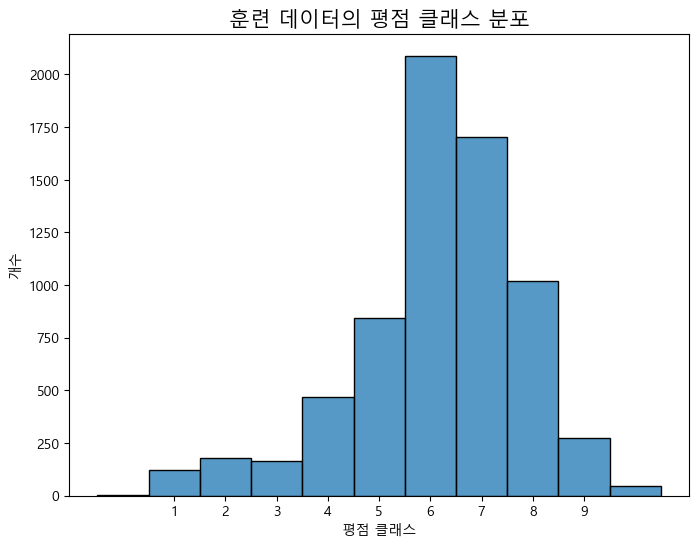


--- CatBoost 모델 학습 시작 ---
0:	learn: 2.1030607	test: 2.1018921	best: 2.1018921 (0)	total: 152ms	remaining: 2m 31s
100:	learn: 0.3925860	test: 0.4370568	best: 0.4370568 (100)	total: 13.1s	remaining: 1m 56s
200:	learn: 0.3357966	test: 0.3911741	best: 0.3911741 (200)	total: 28.2s	remaining: 1m 52s
300:	learn: 0.3180889	test: 0.3812167	best: 0.3811698 (299)	total: 50.8s	remaining: 1m 57s
400:	learn: 0.3091784	test: 0.3786789	best: 0.3786789 (400)	total: 1m 14s	remaining: 1m 50s
500:	learn: 0.2988613	test: 0.3750269	best: 0.3750257 (499)	total: 1m 36s	remaining: 1m 36s
600:	learn: 0.2902945	test: 0.3720980	best: 0.3719462 (596)	total: 1m 59s	remaining: 1m 19s
700:	learn: 0.2817243	test: 0.3690445	best: 0.3690411 (695)	total: 2m 22s	remaining: 1m
800:	learn: 0.2742509	test: 0.3674201	best: 0.3673614 (796)	total: 2m 43s	remaining: 40.6s
900:	learn: 0.2686589	test: 0.3669519	best: 0.3669519 (900)	total: 2m 56s	remaining: 19.4s
999:	learn: 0.2633226	test: 0.3658890	best: 0.3658890 (999)	total: 

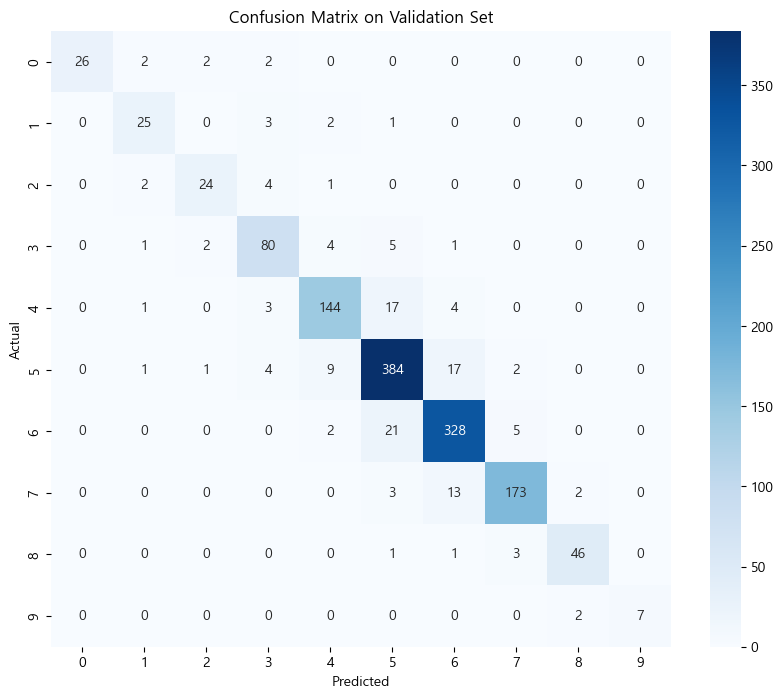


--- 테스트 데이터 로드 및 전처리 시작 ---

--- 매핑되지 않은 감독 이름을 찾습니다 (수동 추가 필요) ---
매핑되지 않은 감독: '아베 노리유키'
매핑되지 않은 감독: '박재인'
매핑되지 않은 감독: '장 뤽 고다르'
매핑되지 않은 감독: '밀러스 포먼'
매핑되지 않은 감독: '이소민'
매핑되지 않은 감독: '존 추'
매핑되지 않은 감독: '모함마드 라술로프'
매핑되지 않은 감독: '김홍익'
매핑되지 않은 감독: '이광복'
매핑되지 않은 감독: '임대희'
매핑되지 않은 감독: '야마나카 요코'
매핑되지 않은 감독: '라이언 쿠글러'
매핑되지 않은 감독: '레니 할린'
매핑되지 않은 감독: '아담 B. 스테인, 잭 리포브스키'
매핑되지 않은 감독: '쿄고쿠 타카히코'
매핑되지 않은 감독: '조세영'
매핑되지 않은 감독: '딘 플라이셔 캠프'
매핑되지 않은 감독: '크리스토퍼 맥쿼리'
매핑되지 않은 감독: '김현지'
매핑되지 않은 감독: '빅토르 에리세'
매핑되지 않은 감독: '코랄리 파르쟈'
매핑되지 않은 감독: '브래디 코베'
매핑되지 않은 감독: '소라 네오'
매핑되지 않은 감독: '한만택'
매핑되지 않은 감독: '이상호'
매핑되지 않은 감독: '조지 황'
매핑되지 않은 감독: '이윤호'
매핑되지 않은 감독: '토미노 요시유키'
매핑되지 않은 감독: '미야 시게유키'
매핑되지 않은 감독: '김성식'
매핑되지 않은 감독: '최이현'
매핑되지 않은 감독: '조경호'
매핑되지 않은 감독: '최종학'
매핑되지 않은 감독: '전성우, 문승욱'
매핑되지 않은 감독: '안느 퐁텐'
매핑되지 않은 감독: '배민'
매핑되지 않은 감독: '시라이시 코지'
매핑되지 않은 감독: '자레드 헤스'
매핑되지 않은 감독: '구자환'
매핑되지 않은 감독: '올리비에 마세-드파스'
매핑되지 않은 감독: '파얄 카파디아'
매핑되지 않은 감독: '최진욱'
매핑되지 않은 감독: '크리스토퍼 랜던'
매핑되지 않은 감독: '남동협'
매핑되지 않은 감독: '마이클 그레이시'
매핑되지

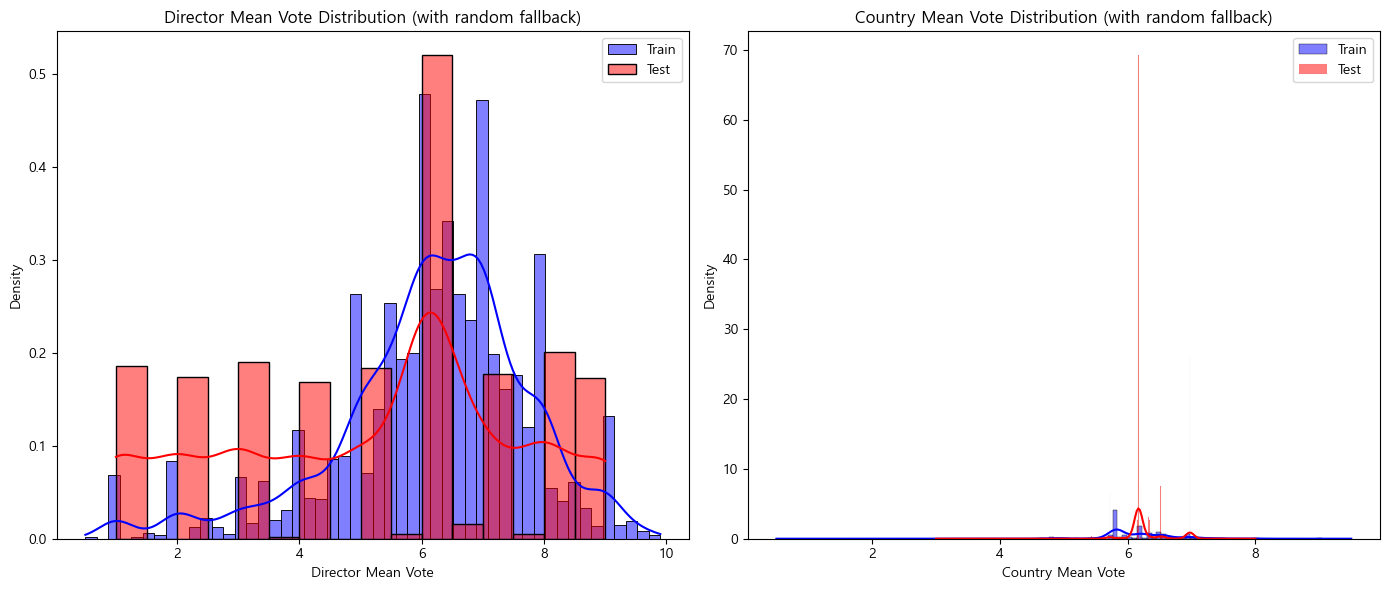


--- 테스트 데이터 예측 시작 ---

--- 예측 확률을 기반으로 평점 클래스 랜덤 샘플링 ---

Test Set Predictions (Sampled Vote Classes):
[7 7 8 ... 4 6 8]
--- 예측 완료 ---

--- 예측 결과를 원본 df_test에 '평점' 컬럼으로 추가 ---
                  title  평점  \
0                태양의 노래   7   
1                   좀비딸   7   
2                  바이러스   8   
3              우리 둘 사이에   7   
4                엣 더 벤치   7   
5              배드 가이즈 2   9   
6   방탄소년단 아미: 포에버 위 아 영   5   
7     반 고흐. 밀밭과 구름 낀 하늘   8   
8   고고다이노 극장판: 게코도마뱀의 꿈   7   
9         젖 큰 자매 수상한 형제   6   
10                 메가 킹   3   
11               왓 리메인즈   7   
12   남친보다 부장님이 좋아요 무삭제판   7   
13       어른이 된 여동생 무삭제판   7   
14                  플로우   9   
15            전지적 독자 시점   7   
16           꼬마마법사 주니토니   7   
17                더 킬러스   7   
18       판타스틱 4: 새로운 출발   8   
19               슬리핑 독스   9   

                                             director        country  \
0                                        Jo Young-jun    South Korea   
1                          

In [ ]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import matplotlib.font_manager as fm
import warnings

warnings.filterwarnings("ignore")

font_path = "C:/Windows/Fonts/malgun.ttf"
try:
    font_name = fm.FontProperties(fname=font_path).get_name()
    matplotlib.rc('font', family=font_name)
    print(f"폰트 설정 완료: {font_name}")
except Exception as e:
    print(f"폰트 설정 실패: {e}. 기본 폰트로 진행합니다.")


print("--- 훈련 데이터 로드 및 전처리 시작 ---")
df = pd.read_csv('tmdb_train_data.csv')

df.rename(columns={
    '영화명': 'title',
    '감독': 'director',
    '제작국가': 'country',
    '개봉일': 'release_date',
    '장르': 'genres',
    '평점': 'vote_average'
}, inplace=True)

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

min_year = df['release_date'].dt.year.min()
df['release_year'] = df['release_date'].dt.year - min_year
df['release_month'] = df['release_date'].dt.month
df['release_weekday'] = df['release_date'].dt.weekday

df = df[(df['vote_average'] > 0) & (df['vote_average'] < 10)]
df = df.dropna(subset=['vote_average', 'genres', 'director', 'country'])

df['vote_class'] = df['vote_average'].round().astype(int)

df['main_genre'] = df['genres'].apply(lambda x: x.split('|')[0] if pd.notnull(x) and '|' in x else x)
df['main_genre'] = df['main_genre'].fillna('Unknown')

df = pd.get_dummies(df, columns=['main_genre'], prefix='genre')

cat_features = ['director', 'country']
for col in cat_features:
    df[col] = df[col].fillna('Unknown').astype(str)

director_mean_vote_train_map = df.groupby('director')['vote_average'].mean()
country_mean_vote_train_map = df.groupby('country')['vote_average'].mean()
overall_mean_vote_train = df['vote_average'].mean()

df['director_mean_vote'] = df['director'].map(director_mean_vote_train_map).fillna(overall_mean_vote_train)
df['country_mean_vote'] = df['country'].map(country_mean_vote_train_map).fillna(overall_mean_vote_train)


features = ['release_year', 'release_month', 'release_weekday'] + \
           list(df.columns[df.columns.str.startswith('genre_')]) + \
           cat_features + ['director_mean_vote', 'country_mean_vote']

X = df[features]
y = df['vote_class']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

cat_features_indices_train = [X_train.columns.get_loc(c) for c in cat_features]

print("--- 훈련 데이터 전처리 완료 ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_valid shape: {X_valid.shape}")


plt.figure(figsize=(8, 6))
sns.histplot(df['vote_class'], bins=np.arange(1, 11) - 0.5, discrete=True, kde=False)
plt.title('훈련 데이터의 평점 클래스 분포', fontsize=15)
plt.xlabel('평점 클래스')
plt.ylabel('개수')
plt.xticks(np.arange(1, 10))
plt.show()

print("\n--- CatBoost 모델 학습 시작 ---")
model = CatBoostClassifier(
    iterations=1000,
    depth=7,
    learning_rate=0.05,
    l2_leaf_reg=5,
    loss_function='MultiClass',
    verbose=100,
    random_seed=42,
    early_stopping_rounds=100
)

model.fit(
    X_train, y_train,
    cat_features=cat_features_indices_train,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=100
)
print("--- CatBoost 모델 학습 완료 ---")

y_pred = model.predict(X_valid)
accuracy = accuracy_score(y_valid, y_pred)
print(f"\nValidation Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_valid, y_pred))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_valid, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix on Validation Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\n--- 테스트 데이터 로드 및 전처리 시작 ---")
df_test = pd.read_csv('test_data.csv')

df_test.rename(columns={
    '영화명': 'title',
    '감독': 'director',
    '제작국가': 'country',
    '개봉일': 'release_date',
    '장르': 'genres'
}, inplace=True)


df_test['release_date'] = pd.to_datetime(df_test['release_date'], errors='coerce')

df_test['release_year'] = df_test['release_date'].dt.year - min_year
df_test['release_month'] = df_test['release_date'].dt.month
df_test['release_weekday'] = df_test['release_date'].dt.weekday

def get_random_vote():
    return random.randint(1, 9)

def translate_composite_names_with_random_fallback(name_str, mapping_dict, separator='|', secondary_separator=','):
    if pd.isnull(name_str):
        return 'Unknown_Random' 
    
    translated_parts = []
    parts = str(name_str).split(separator)
    if len(parts) == 1 and secondary_separator in parts[0]: 
        parts = parts[0].split(secondary_separator)
    
    for part in parts:
        p_stripped = part.strip()
        translated_parts.append(mapping_dict.get(p_stripped, 'Unknown_Random')) 
    return (separator if separator == '|' else ', ').join(translated_parts)

country_mapping = {
    '대한민국': 'South Korea', '한국': 'South Korea',
    '미국': 'United States', '일본': 'Japan', '영국': 'United Kingdom',
    '프랑스': 'France', '독일': 'Germany', '중국': 'China', '캐나다': 'Canada',
    '인도': 'India', '스페인': 'Spain', '이탈리아': 'Italy', '러시아': 'Russia',
    '호주': 'Australia', '멕시코': 'Mexico', '스웨덴': 'Sweden', '덴마크': 'Denmark',
    '노르웨이': 'Norway', '핀란드': 'Finland', '벨기에': 'Belgium', '네덜란드': 'Netherlands',
    '아일랜드': 'Ireland', '뉴질랜드': 'New Zealand', '브라질': 'Brazil', '아르헨티나': 'Argentina',
    '남아프리카 공화국': 'South Africa', '홍콩': 'Hong Kong', '대만': 'Taiwan',
    '체코': 'Czech Republic', '폴란드': 'Poland', '오스트리아': 'Austria',
    '스위스': 'Switzerland', '그리스': 'Greece', '포르투갈': 'Portugal',
    '튀르키예': 'Turkey', '터키': 'Turkey',
    '이스라엘': 'Israel', '이란': 'Iran', '이집트': 'Egypt',
    '콜롬비아': 'Colombia', '태국': 'Thailand', '필리핀': 'Philippines',
    '인도네시아': 'Indonesia', '베트남': 'Vietnam', '싱가포르': 'Singapore',
    '아랍에미리트': 'United Arab Emirates', '사우디아라비아': 'Saudi Arabia',
    '아이슬란드': 'Iceland', '헝가리': 'Hungary', '루마니아': 'Romania',
    '불가리아': 'Bulgaria', '크로아티아': 'Croatia', '세르비아': 'Serbia',
    '슬로베니아': 'Slovenia', '슬로바키아': 'Slovakia', '에스토니아': 'Estonia',
    '라트비아': 'Latvia', '리투아니아': 'Lithuania', '우크라이나': 'Ukraine',
    '아제르바이잔': 'Azerbaijan', '카자흐스탄': 'Kazakhstan', '우즈베키스탄': 'Uzbekistan',
    '조지아': 'Georgia', '아르메니아': 'Armenia', '벨라루스': 'Belarus',
    '에티오피아': 'Ethiopia', '케냐': 'Kenya', '나이지리아': 'Nigeria', '모로코': 'Morocco',
    '튀니지': 'Tunisia', '알제리': 'Algeria', '레바논': 'Lebanon', '요르단': 'Jordan',
    '시리아': 'Syria', '이라크': 'Iraq', '예멘': 'Yemen', '아프가니스탄': 'Afghanistan',
    '파키스탄': 'Pakistan', '방글라데시': 'Bangladesh', '스리랑카': 'Sri Lanka',
    '네팔': 'Nepal', '부탄': 'Bhutan', '몽골': 'Mongolia', '쿠바': 'Cuba',
    '도미니카 공화국': 'Dominican Republic', '자메이카': 'Jamaica', '트리니다드 토바고': 'Trinidad and Tobago',
    '바하마': 'Bahamas', '바베이도스': 'Barbados', '도미니카': 'Dominica',
    '세인트루시아': 'Saint Lucia', '세인트빈센트 그레나딘': 'Saint Vincent and the Grenadines',
    '그레나다': 'Grenada', '앤티가 바부다': 'Antigua and Barbuda', '벨리즈': 'Belize',
    '코스타리카': 'Costa Rica', '엘살바도르': 'El Salvador', '과테말라': 'Guatemala',
    '온두라스': 'Honduras', '니카라과': 'Nicaragua', '파나마': 'Panama',
    '우루과이': 'Uruguay', '파라과이': 'Paraguay',
    '덴마크령': 'Denmark',
    '오스트리아 ,영국': 'Austria, United Kingdom',
    '기타': 'Unknown',
    np.nan: 'Unknown', '': 'Unknown'
}
df_test['country'] = df_test['country'].apply(lambda x: translate_composite_names_with_random_fallback(x, country_mapping, separator=',', secondary_separator=','))
df_test['country'] = df_test['country'].astype(str).replace(r'^[가-힣\s,]+$', 'Unknown', regex=True)


genre_mapping = {
    '드라마': 'Drama', '액션': 'Action', '코미디': 'Comedy', '스릴러': 'Thriller',
    '범죄': 'Crime', '판타지': 'Fantasy', 'SF': 'Science Fiction', '모험': 'Adventure',
    '애니메이션': 'Animation', '가족': 'Family', '공포': 'Horror', '미스터리': 'Mystery',
    '로맨스': 'Romance', '역사': 'History', '전쟁': 'War', '음악': 'Music',
    '다큐멘터리': 'Documentary', '서부': 'Western', 'TV 영화': 'TV Movie',
    '공포(호러)': 'Horror',
    '공연': 'Concert', '스포츠': 'Sport', '성인': 'Adult', '실험': 'Experimental',
    '컬트': 'Cult', '느와르': 'Noir', '뮤지컬': 'Musical',
    '다큐': 'Documentary', '사극': 'Historical Drama', '서부극(웨스턴)': 'Western',
    '기타': 'Unknown',
    np.nan: 'Unknown', '': 'Unknown'
}
df_test['genres'] = df_test['genres'].apply(lambda x: translate_composite_names_with_random_fallback(x, genre_mapping, separator='|', secondary_separator=','))
df_test['main_genre'] = df_test['genres'].apply(lambda x: x.split('|')[0].strip() if pd.notnull(x) and '|' in x else x.strip())
df_test['main_genre'] = df_test['main_genre'].fillna('Unknown')


print("\n--- 매핑되지 않은 감독 이름을 찾습니다 (수동 추가 필요) ---")
director_mapping = {
    '조영준': 'Jo Young-jun', '필감성': 'Pil Gam-seong', '강이관': 'Kang Yi-kwan', '성지혜': 'Seong Ji-hye',
    '오쿠야마 요시유키': 'Okuyama Yoshiyuki', '피에르 페리펠': 'Pierre Perifel', '이원재': 'Lee Won-jae',
    '나단 스코긴스': 'Nathan Scoggins', '킨피카하누케마루': 'Kin-pika Hanukemaru', '사토 이노스케': 'Sato Inosuke',
    '긴츠 질발로디스': 'Gints Zilbalodis', '김병우': 'Kim Byung-woo', '서동해': 'Seo Dong-hae',
    '김종관, 노덕, 장항준, 이명세': 'Kim Jong-kwan, Roh Deok, Jang Hang-jun, Lee Myung-se',
    '맷 샤크먼': 'Matt Shakman', '변희선': 'Byun Hee-sun', '사토 마사코': 'Sato Masako',
    '김호락': 'Kim Ho-rak', '소토자키 하루오': 'Sotozaki Haruo', '게도 하루히코': 'Gedo Haruhiko',
    '소마이 신지': 'Somai Shinji', '조성규': 'Jo Sung-kyu', '유하': 'Yoo Ha',
    '김성환': 'Kim Seong-hwan', '페데리코 펠리니': 'Federico Fellini', '시게하라 카츠야': 'Shigehara Katsuy' ,
    '테라모토 유키요': 'Teramoto Yukiyo', '유진주': 'Yu Jin-joo',
    '박정례, 이지윤': 'Park Jung-rae, Lee Ji-yoon',
    '히시다 마사카즈': 'Hishida Masakazu', '이시카와 준이치': 'Ishikawa Junichi', '노홍진': 'Na Hong-jin',
    '촹칭션': 'Chuang Ching-shen', '강형철': 'Kang Hyeong-cheol', '키토루네 가와구치': 'Kitorune Kawaguchi',
    '장성호': 'Jang Sung-ho', '신재민': 'Shin Jae-min',
    '박민수, 안건형': 'Park Min-soo, Ahn Gun-hyung',
    '알랭 기로디': 'Alain Guiraudie', '제라드 존스톤': 'Gerald Johnstone', '정초신': 'Jeong Cho-sin',
    '신연식': 'Shin Yeon-shick', '이치엔': 'Li Qian', '강미자': 'Kang Mi-ja',
    '가렛 에드워즈': 'Gareth Edwards', '최정문': 'Choi Jeong-mun', '김수진': 'Kim Su-jin',
    '미츠나카 스스무': 'Mitsunaka Susumu', '이시하라 타츠야': 'Ishihara Tatsuy', '장병기': 'Jang Byung-ki',
    '릴리 피니 자눅': 'Lili Fini Zanuck', '심용': 'Sim Yong',
    '봉준호': 'Bong Joon-ho', '박찬욱': 'Park Chan-wook', '김기덕': 'Kim Ki-duk',
    '이창동': 'Lee Chang-dong', '홍상수': 'Hong Sang-soo', '류승완': 'Ryoo Seung-wan',
    '최동훈': 'Choi Dong-hoon', '나홍진': 'Na Hong-jin', '윤제균': 'Yoon Je-kyoon',
    '장준환': 'Jang Joon-hwan', '김성수': 'Kim Sung-su',
    '이병헌': 'Lee Byeong-heon', 
    '김지운': 'Kim Jee-woon', '김용화': 'Kim Yong-hwa', '이준익': 'Lee Joon-ik',
    '황동혁': 'Hwang Dong-hyuk', '변성현': 'Byun Sung-hyun', '연상호': 'Yeon Sang-ho',
    '이정재': 'Lee Jung-jae', 
    '엄유나': 'Um You-na', '장재현': 'Jang Jae-hyun', '한재림': 'Han Jae-rim',
    '이상용': 'Lee Sang-yong', '이한': 'Lee Han', '장항준': 'Jang Hang-jun',
    '김한민': 'Kim Han-min', '오승욱': 'Oh Seung-uk', '임찬익': 'Lim Chan-ik',
    '조성희': 'Jo Sung-hee', '박훈정': 'Park Hoon-jung', '배종': 'Bae Jong',
    '원신연': 'Won Shin-yeon', '우민호': 'Woo Min-ho', '이경미': 'Lee Kyoung-mi',
    '이해영': 'Lee Hae-young', '김민호': 'Kim Min-ho', '김병우': 'Kim Byung-woo',
    '이재규': 'Lee Jae-kyoo', '이정범': 'Lee Jeong-beom', '전계수': 'Jeon Kye-soo',
    '정지우': 'Jung Ji-woo', '김용균': 'Kim Yong-gyun', '윤종빈': 'Yoon Jong-bin',
    '최정열': 'Choi Jeong-yeol', '김태용': 'Kim Tae-kyun', '김혜미': 'Kim Hye-mi',
    '신수원': 'Shin Su-won', '양우석': 'Yang Woo-suk', '허진호': 'Hur Jin-ho',
    '황병국': 'Hwang Byoung-gook', '조의석': 'Jo Ui-seok', '이원석': 'Lee Won-suk',
    '노에미 멜랑': 'Noémie Lvovsky',
    '제임스 건': 'James Gunn',
    '탁세웅': 'Tak Se-ung',
    '이승호, 서오름, 방성훈, 이세영': 'Lee Seung-ho, Seo Oh-reum, Bang Seong-hun, Lee Se-yeong',
    '오세호': 'Oh Se-ho',
    '데이비드 젤너, 나단 젤너': 'David Zellner, Nathan Zellner',
    '남궁선': 'Namkoong Sun',
    '조한별': 'Jo Han-byeol',
    '민규동': 'Min Kyu-dong',
    '루카 구아다니노': 'Luca Guadagnino',
    '정윤철': 'Jeong Yoon-cheol',
    '손승웅': 'Son Seung-ung',
    '도미 시, 매들린 샤라피안, 아드리안 몰리나': 'Domee Shi, Madeleine Sharafian, Adrian Molina',
    '김우석': 'Kim Woo-suk',
    '노세기': 'Noh Sae-gi',
    '대니 보일': 'Danny Boyle',
    '호나스 트루에바': 'Jonás Trueba',
    '오카다 마리': 'Mari Okada',
    '데이비드 크로넨버그': 'David Cronenberg',
    '조셉 코신스키': 'Joseph Kosinski',
    '김재훈': 'Kim Jae-hun',
    '유지태': 'Yu Ji-tae',
    '서재경': 'Seo Jae-kyung',
    '강영만': 'Kang Young-man',
    '전규환': 'Jeon Kyu-hwan',
    '유진': 'Yoo Jin',
    '곽경택': 'Kwak Kyung-taek',
    '김상진': 'Kim Sang-jin',
    '김대승': 'Kim Dae-seung',
    '최승원': 'Choi Seung-won',
    '최원섭': 'Choi Won-sub',
    '이경규': 'Lee Kyung-kyu',
    '강지은': 'Kang Ji-eun',
    '김선': 'Kim Sun',
    '정대만': 'Jeong Dae-man',
    '박성훈': 'Park Sung-hoon',
    '신성훈': 'Shin Sung-hun',
    '임진수': 'Lim Jin-soo',
    '이창근': 'Lee Chang-geun',
    '김대우': 'Kim Dae-woo',
    '주성진': 'Joo Sung-jin',
    '이도윤': 'Lee Do-yoon',
    '한철수': 'Han Cheol-soo',
    '최진원': 'Choi Jin-won',
    '조용익': 'Jo Yong-ik',
    '안재석': 'Ahn Jae-seok',
    '임성운': 'Lim Sung-woon',
    '김준성': 'Kim Jun-seong',
    '김영남': 'Kim Young-nam',
    '김도형': 'Kim Do-hyung',
    '김지연': 'Kim Ji-yeon',
    '이상우': 'Lee Sang-woo',
    '이종필': 'Lee Jong-pil',
    '박정우': 'Park Jung-woo',
    '백종열': 'Baek Jong-yeol',
    '최해준': 'Choi Hae-jun',
    '이해준': 'Lee Hae-jun',
    '김진유': 'Kim Jin-yoo',
    '김태균': 'Kim Tae-kyun',
    '오인천': 'Oh In-cheon',
    '임권택': 'Im Kwon-taek',
    '류승범': 'Ryoo Seung-bum',
    '김홍선': 'Kim Hong-sun',
    '한상혁': 'Han Sang-hyuk',
    '이용주': 'Lee Yong-joo',
    '김동원': 'Kim Dong-won',
    '조근현': 'Jo Geun-hyun',
    '허진호': 'Huh Jin-ho',
    '김휘': 'Kim Hwi',
    '송해성': 'Song Hae-sung',
    '최종태': 'Choi Jong-tae',
    '장희철': 'Jang Hee-chul',
    '박희곤': 'Park Hee-gon',
    '이승환': 'Lee Seung-hwan',
    '심형래': 'Shim Hyung-rae',
    '배창호': 'Bae Chang-ho',
    '신동엽': 'Shin Dong-yeob',
    '오달수': 'Oh Dal-su',
    '이장호': 'Lee Jang-ho',
    '안국진': 'Ahn Gooc-jin',
    '정성일': 'Jung Sung-il',
    '김정환': 'Kim Jung-hwan',
    '이종언': 'Lee Jong-eon',
    '김윤석': 'Kim Yoon-seok',
    '방은진': 'Bang Eun-jin',
    '임순례': 'Yim Soon-rye',
    '곽재용': 'Kwak Jae-yong',
    '이계벽': 'Lee Gye-byeok',
    '이도엽': 'Lee Do-yeob',
    '남대중': 'Nam Dae-jung',
    '오승호': 'Oh Seung-ho',
    '신상옥': 'Shin Sang-ok',
    '강윤성': 'Kang Yoon-sung',
    '조병석': 'Jo Byung-seok',
    '김봉주': 'Kim Bong-joo',
    '오명훈': 'Oh Myoung-hoon',
    '이상근': 'Lee Sang-geun',
    '이정호': 'Lee Jung-ho',
    '김대진': 'Kim Dae-jin',
    '이한종': 'Lee Han-jong',
    '김성훈': 'Kim Seong-hun',
    '유영식': 'Yoo Young-sik',
    '김동현': 'Kim Dong-hyun',
    '전재홍': 'Jeon Jae-hong',
    '박진표': 'Park Jin-pyo',
    '임진순': 'Lim Jin-soon',
    '김명균': 'Kim Myung-gyun',
    '이원태': 'Lee Won-tae',
    '조정래': 'Jo Jung-rae',
    '허정': 'Huh Jung',
    '이윤기': 'Lee Yoon-ki',
    '박누리': 'Park Nuri',
    '강효진': 'Kang Hyo-jin',
    '김민정': 'Kim Min-jung',
    '최성은': 'Choi Sung-eun',
    '오윤동': 'Oh Yoon-dong',
    '이로운': 'Lee Ro-un',
    '한동호': 'Han Dong-ho',
    '최정자': 'Choi Jeong-ja',
    '이수성': 'Lee Su-seong',
    '박은석': 'Park Eun-seok',
    '에로핑': 'Eroping',
    '조윤수': 'Jo Yoon-soo',
    '아사기리 키요시': 'Asagiri Kiyoshi',
    '가이 리치': 'Guy Ritchie',
    '미즈시마 츠토무': 'Mizushima Tsutomu',
    '박재석': 'Park Jae-seok',
    '나기라 겐조': 'Nagira Kenzo',
    '김문옥': 'Kim Moon-ok',
    '스콧 제프리': 'Scott Jeffrey',
    '이광범': 'Lee Kwang-beom',
    '안노 히데아키': 'Anno Hideaki',
    '황승재': 'Hwang Seung-jae',
    '박준수': 'Park Joon-soo',
    '사토 신스케': 'Sato Shinsuke',
    '이상수': 'Lee Sang-soo',
    '등연성': 'Deng Yancheng',
    '츠루마키 카즈야': 'Tsurumaki Kazuya',
    '셀린 시아마': 'Céline Sciamma',
    '리들리 스콧': 'Ridley Scott',
    '크리스토퍼 포브스': 'Christopher Forbes',
    '핑마': 'Ping Ma',
    '김충길': 'Kim Choong-gil',
    '장예모': 'Zhang Yimou',
    '이승준': 'Lee Seung-jun',
    '손석': 'Son Seok',
    '손현우': 'Son Hyun-woo',
    '김하민': 'Kim Ha-min',
    '바실리 로벤스키': 'Vasily Rovenskiy',
    '나카타 히데오': 'Nakata Hideo',
    '크리스티안 펫졸드': 'Christian Petzold',
    '야마시타 노부히로': 'Yamashita Nobuhira',
    '하마구치 류스케': 'Hamaguchi Ryusuke',
    '이시카와 지로': 'Ishikawa Jiro',
    '유야마 쿠니히코': 'Yuyama Kunihiko',
    '브렛 벤트먼': 'Brett Bentman',
    '자레드 콘': 'Jared Cohn',
    '후쿠다 유이치': 'Fukuda Yuichi',
    '현우성': 'Hyun Woo-sung',
    '웨스 앤더슨': 'Wes Anderson',
    '고봉수': 'Ko Bong-soo',
    '권순도': 'Kwon Soon-do',
    '카키모토 코다이': 'Kakimoto Kodai', 
    '이수정': 'Lee Su-jeong',
    '빅터 부': 'Victor Vu',
    '김지애': 'Kim Ji-ae',
    '박중하': 'Park Joong-ha',
    '사쿠라기 유헤이': 'Sakuragi Yuhei',
    '김종면, 이선정': 'Kim Jong-myeon, Lee Seon-jeong',
    '정윤철, 정상진': 'Jeong Yoon-cheol, Jeong Sang-jin',
    '변성빈': 'Byun Sung-bin',
    '개리 쇼어': 'Gary Shore',
    '권혁재': 'Kwon Hyuk-jae',
    '스티븐 C. 밀러': 'Steven C. Miller',
    '지오바니 푸무': 'Giovanni Fumu',
    '레오 파비에': 'Léo Favier',
    '대니 필리푸, 마이클 필리푸': 'Danny Philippou, Michael Philippou',
    '딘 데블로이스': 'Dean DeBlois',
    '아담 엘리어트': 'Adam Elliot',
    '올레흐 우라자이킨': 'Oleh Urazayev',
    '김채영': 'Kim Chae-young',
    '롤라 키보론': 'Lola Kibréon',
    '아메미야 아키라': 'Amemiya Akira',
    '박동희': 'Park Dong-hee',
    '박소현, 송영윤': 'Park So-hyun, Song Young-yoon',
    '류연수': 'Ryu Yeon-soo',
    '허영철': 'Heo Young-cheol',
    '이마무라 쇼헤이': 'Imamura Shohei',
    '사부': 'Sabu',
    '로버트 에거스': 'Robert Eggers',
    '김용진': 'Kim Yong-jin',
    '조나단 유세비오': 'Jonathan Eusebio',
    '아톰 에고이안': 'Atom Egoyan',
    '후지모리 마사야': 'Fujimori Masaya',
    '제이크 슈레이어': 'Jake Schreier',
    '유수연': 'Yoo Su-yeon',
    '알렉스 켄드릭': 'Alex Kendrick',
    '매들린 개빈': 'Madeleine Gavin',
    '김상래': 'Kim Sang-rae',
    
    '' : 'Unknown',
    np.nan: 'Unknown'
}

for d in df_test['director'].unique():
    if d not in director_mapping and any('\uac00' <= char <= '\ud7a3' for char in str(d)):
        print(f"매핑되지 않은 감독: '{d}'")
print("--- 매핑되지 않은 감독 이름 검색 완료 ---")

df_test['director'] = df_test['director'].apply(lambda x: translate_composite_names_with_random_fallback(x, director_mapping, separator=',', secondary_separator=','))
df_test['director'] = df_test['director'].astype(str).replace(r'^[가-힣\s,]+$', 'Unknown_Random', regex=True)


print("--- 한글 값을 영어로 변환 완료 (매핑되지 않은 감독은 'Unknown_Random'으로 임시 처리) ---")

for col in cat_features:
    df_test[col] = df_test[col].fillna('Unknown_Random').astype(str)


test_genres_dummies = pd.get_dummies(df_test['main_genre'], prefix='genre')
train_genre_cols = [col for col in df.columns if col.startswith('genre_')]

for col in train_genre_cols:
    if col not in test_genres_dummies.columns:
        test_genres_dummies[col] = 0
test_genres_dummies = test_genres_dummies[train_genre_cols]

non_genre_features_for_X_test = ['release_year', 'release_month', 'release_weekday'] + \
                                 cat_features + ['director_mean_vote', 'country_mean_vote']

X_test_base = df_test[non_genre_features_for_X_test]
X_test = pd.concat([X_test_base, test_genres_dummies], axis=1)

training_features_order = features
X_test = X_test.reindex(columns=training_features_order, fill_value=0)

print("--- 테스트 데이터 전처리 완료 ---")
print(f"X_test shape: {X_test.shape}")


print("\n--- X_train과 X_test 컬럼 일치 여부 최종 확인 ---")
columns_set_match = set(X_train.columns) == set(X_test.columns)
print(f"컬럼 집합 일치 여부 (이름만, 순서 무관): {columns_set_match}")
columns_exact_match = X_train.columns.equals(X_test.columns)
print(f"컬럼 이름 및 순서 정확히 일치 여부: {columns_exact_match}")

if columns_set_match and columns_exact_match:
    print("\nX_train과 X_test의 컬럼 이름과 순서가 완벽하게 일치합니다!")
else:
    print("\nX_train과 X_test의 컬럼에 불일치가 있습니다. 상세 정보를 확인하세요.")
    if not columns_set_match:
        missing_in_test = set(X_train.columns) - set(X_test.columns)
        extra_in_test = set(X_test.columns) - set(X_train.columns)
        if missing_in_test:
            print(f"  X_test에 없는 X_train 컬럼: {missing_in_test}")
        if extra_in_test:
            print(f"  X_test에만 있는 컬럼: {extra_in_test}")
    elif not columns_exact_match:
        print("  컬럼 이름은 같으나 순서가 다릅다.")

print("\n--- 'director_mean_vote' 및 'country_mean_vote' 분포 최종 확인 (매핑 후) ---")
print("X_test['director_mean_vote'] describe():\n", X_test['director_mean_vote'].describe())
print("\nX_test['country_mean_vote'] describe():\n", X_test['country_mean_vote'].describe())

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(X_train['director_mean_vote'], color='blue', label='Train', kde=True, stat='density', alpha=0.5)
sns.histplot(X_test['director_mean_vote'], color='red', label='Test', kde=True, stat='density', alpha=0.5)
plt.title('Director Mean Vote Distribution (with random fallback)')
plt.xlabel('Director Mean Vote')
plt.legend()

plt.subplot(1, 2, 2)
sns.histplot(X_train['country_mean_vote'], color='blue', label='Train', kde=True, stat='density', alpha=0.5)
sns.histplot(X_test['country_mean_vote'], color='red', label='Test', kde=True, stat='density', alpha=0.5)
plt.title('Country Mean Vote Distribution (with random fallback)')
plt.xlabel('Country Mean Vote')
plt.legend()

plt.tight_layout()
plt.show()


print("\n--- 테스트 데이터 예측 시작 ---")
cat_features_indices_test = [X_test.columns.get_loc(c) for c in cat_features]
test_pool = Pool(data=X_test, cat_features=cat_features_indices_test)

print("\n--- 예측 확률을 기반으로 평점 클래스 랜덤 샘플링 ---")
y_test_pred_proba = model.predict_proba(test_pool)

def sample_from_proba(probas):
    classes = np.arange(1, len(probas) + 1)
    return np.random.choice(classes, p=probas)

y_test_pred_sampled = np.apply_along_axis(sample_from_proba, 1, y_test_pred_proba)

print("\nTest Set Predictions (Sampled Vote Classes):")
print(y_test_pred_sampled)
print("--- 예측 완료 ---")

print("\n--- 예측 결과를 원본 df_test에 '평점' 컬럼으로 추가 ---")
df_test['평점'] = y_test_pred_sampled.astype(int)

print(df_test[['title', '평점', 'director', 'country', 'genres']].head(20))
print(f"\n업데이트된 df_test의 shape: {df_test.shape}")


In [38]:
df_test = df_test.drop(columns=['release_year', 'release_month', 'release_weekday', 'main_genre', 'director_mean_vote', 'country_mean_vote'])

output_filename = 'predicted_movie_ratings.csv'
df_test.to_csv(output_filename, index=False)
print(f"\n예측 결과가 포함된 데이터프레임이 '{output_filename}' 파일로 저장")


예측 결과가 포함된 데이터프레임이 'predicted_movie_ratings.csv' 파일로 저장


### 실패작들

In [3]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth': [3,5,7,9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 300, 500, 1000],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1,3,5],
}

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

random_search = RandomizedSearchCV(
    xgb_model, param_distributions=param_dist,
    n_iter=30, scoring='neg_root_mean_squared_error',
    cv=3, verbose=2, random_state=42
)

random_search.fit(X_train, y_train)
print("Best params:", random_search.best_params_)
print("Best RMSE:", -random_search.best_score_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, min_child_weight=3, n_estimators=1000, subsample=1.0; total time=   0.5s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, min_child_weight=3, n_estimators=1000, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, min_child_weight=3, n_estimators=1000, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=5, min_child_weight=3, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=5, min_child_weight=3, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=5, min_child_weight=3, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=5, min_child_weight=3, n_estimators=300, subsample=0.8; tot

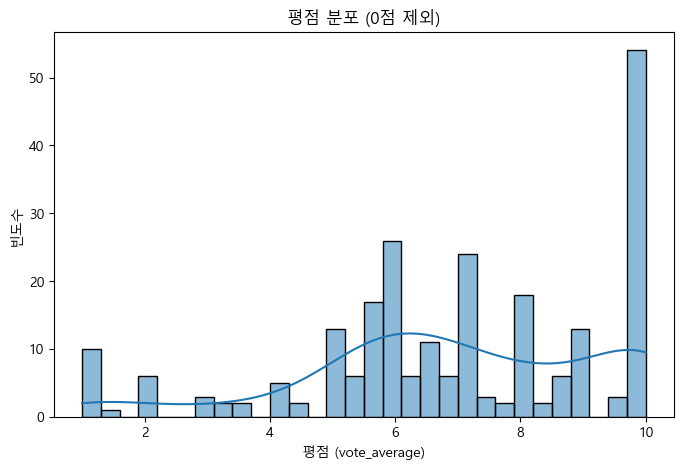

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import matplotlib.font_manager as fm

font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = fm.FontProperties(fname=font_path).get_name()
matplotlib.rc('font', family=font_name)

filtered_df = df[df['vote_average'] > 0]

plt.figure(figsize=(8,5))
sns.histplot(filtered_df['vote_average'], bins=30, kde=True)
plt.title('평점 분포 (0점 제외)')
plt.xlabel('평점 (vote_average)')
plt.ylabel('빈도수')
plt.show()


In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

filtered_df = df[df['vote_average'] > 0].copy()

X = filtered_df.drop(columns=['vote_average', 'title', 'release_date']) 
y = filtered_df['vote_average']

from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

import xgboost as xgb

model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=50)

y_pred = model.predict(X_valid)

mse = mean_squared_error(y_valid, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_valid, y_pred)
r2 = r2_score(y_valid, y_pred)

print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation MAE: {mae:.4f}")
print(f"Validation R^2: {r2:.4f}")

[0]	validation_0-rmse:1.97028


[50]	validation_0-rmse:1.94784
[99]	validation_0-rmse:1.99181
Validation RMSE: 1.9918
Validation MAE: 1.5021
Validation R^2: 0.0293


In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MultiLabelBinarizer
import xgboost as xgb

df = pd.read_csv('tmdb_train_data.csv')

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month

df['genres'] = df['genres'].fillna('').apply(lambda x: x.split('|'))
mlb = MultiLabelBinarizer()
genres_encoded = pd.DataFrame(mlb.fit_transform(df['genres']), columns=mlb.classes_, index=df.index)
df = pd.concat([df.drop(columns=['genres']), genres_encoded], axis=1)

df['director'] = df['director'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

director_freq = df['director'].value_counts(normalize=True)
country_freq = df['country'].value_counts(normalize=True)

df['director_freq'] = df['director'].map(director_freq)
df['country_freq'] = df['country'].map(country_freq)

df = df[df['director_freq'] > 0.01]
df = df[df['country_freq'] > 0.01]

df.drop(columns=['title', 'director', 'country', 'release_date'], inplace=True)

df = df[df['vote_average'] > 0]
df.dropna(inplace=True)

X = df.drop(columns=['vote_average'])
y = df['vote_average']
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_valid)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
mae = mean_absolute_error(y_valid, y_pred)
r2 = r2_score(y_valid, y_pred)

print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation MAE: {mae:.4f}")
print(f"Validation R^2: {r2:.4f}")

Validation RMSE: 2.8231
Validation MAE: 2.1585
Validation R^2: -0.3528


In [14]:
train_pred = model.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
print(f"Train RMSE: {train_rmse:.4f}")

Train RMSE: 1.4337


In [18]:
import xgboost as xgb
import numpy as np

dtrain = xgb.DMatrix(X_train, label=y_train)
dvalid = xgb.DMatrix(X_valid, label=y_valid)

params = {
    'objective': 'reg:squarederror',
    'learning_rate': 0.05,
    'max_depth': 4,
    'seed': 42
}

evals = [(dtrain, 'train'), (dvalid, 'valid')]

model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=50
)

y_pred = model.predict(dvalid)
dvalid = xgb.DMatrix(X_valid) 
y_pred = model.predict(dvalid)

rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
mae = mean_absolute_error(y_valid, y_pred)
r2 = r2_score(y_valid, y_pred)

print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation MAE: {mae:.4f}")
print(f"Validation R^2: {r2:.4f}")



[0]	train-rmse:2.41021	valid-rmse:2.43239
[49]	train-rmse:1.95993	valid-rmse:2.57755
Validation RMSE: 2.5784
Validation MAE: 1.9955
Validation R^2: -0.1284
